# Optimized Machine Learning Model for Predicting and Analyzing Accelerations in the New Ground Motion Models for Northern South America (NoSAm GMMs)

La ingenieria sismica es uno de los principales campos frente a la evaluación de riesgos y vulnerabilidad a partir de los desastres naturales, en este caso en específico, los sismos. Teniendo en cuenta variables como la magnitud sísmica (Momento Magnitude Mw), la distancia al hipocentro y el entorno tectónico, se busca predecir la aceleración espectral con un periodo de 0.01 s producidas por los sismos, con el objetivo de obtener un modelo confiable capaz de predecir la aceleración con periodos distintos. 
Los modelos anteriores (NoSAm GMMs) permitieron la estimación de la aceleración espectral con 5% de amortiguamiento en diferentes entornos tectónicos.
 Para ello, se utilizará una base de datos regional con aproximadamente 8800 observaciones recogidas por el Servicio Geológico Colombiano el cual incluye registros de Ecuador y Colombia. A partir de allí se compararán modelos tradicionales de Machine Learning (como KNN, regresión Ridge y Lasso, SVM y XGBoost) con un modelo original de stacking basado en modelos de XGBoost y LightGBM, con el objetivo de mejorar la precisión de predicción respecto a estudios previos y a su vez comparar las métricas generales con los modelos preliminares.

**Palabras clave**:
ingeniería sismica, aceleración, Machine Learning, predicción, riesgos, vulnerabilidad, desastres naturales



## 1. Análisis Exploratorio de datos  (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, explained_variance_score

import scipy.stats as stats
from scipy.stats import kurtosis, boxcox

import mglearn
import matplotlib

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/Copia de DataBaseSGC.csv', delimiter=';', low_memory=False)
df2= pd.read_excel('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/CopiaDataBaseSGC.xlsx')
df


,Record Sequence Number,EQID,Epicenter Latitude (deg; positive N),Epicenter Longitude (deg; positive E),Hypocenter Depth (km),Magnitude,Magnitude type,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),...,Station Elevation (m),Tmax,Valor_T1.5,Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,1,EC_20160416235837,0.35,-79.93,21.0,7.7822,Mw,Interface,27,21,...,2664.0,5,0.12,193.902831,154.345123,160.846919,212.387613,197.997332,28.416246,27.209753
1,2,EC_20160518075703,0.43,-79.79,16.0,6.7001,Mw,Interface,28,18,...,2664.0,2,0.14,218.211371,204.079653,205.275676,204.424794,219.418467,85.273825,4.097850
2,3,EC_20160518164644,0.50,-79.62,30.0,6.8684,Mw,Interface,28,21,...,2664.0,5,0.12,213.354397,194.839359,198.622587,191.386016,216.833228,96.972004,6.819786
3,4,EC_20160416235837,0.35,-79.93,21.0,7.7822,Mw,Interface,27,21,...,13.0,2,0.25,386.687925,319.308209,321.266537,185.456450,388.493021,293.872683,22.289756
4,5,EC_20160518075703,0.43,-79.79,16.0,6.7001,Mw,Interface,28,18,...,13.0,7,0.32,407.841031,387.233044,387.195348,182.156285,408.347566,351.161989,1.875562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,8807,CO_20191227032038,3.41,-74.17,16.0,4.4000,Mw,Crustal,142,83,...,696.0,16,0.15,296.999096,296.065638,296.180748,-31.733134,297.506537,294.384639,0.685194
8807,8808,CO_20200114175709,6.82,-73.15,150.0,4.6000,Mw,Deep,11,90,...,696.0,16,0.07,179.677526,178.188108,231.767387,113.834068,235.373785,137.078999,0.395032
8808,8809,CO_20200117043206,2.12,-79.56,20.0,4.7000,Mw,Interface,44,25,...,696.0,40,0.02,876.174697,873.178545,872.100140,-344.376016,876.453666,802.354454,0.007543
8809,8810,CO_20200120180005,7.27,-78.64,4.0,5.1000,Mw,Crustal,282,68,...,696.0,40,0.02,722.499160,719.534386,719.316553,-55.220635,722.527004,717.775640,0.046228


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8811 entries, 0 to 8810
Data columns (total 30 columns):
 #   Column                                                                                    Non-Null Count  Dtype  
---  ------                                                                                    --------------  -----  
 0   Record Sequence Number                                                                    8811 non-null   int64  
 1   EQID                                                                                      8811 non-null   object 
 2   Epicenter Latitude (deg; positive N)                                                      8811 non-null   float64
 3   Epicenter Longitude (deg; positive E)                                                     8811 non-null   float64
 4   Hypocenter Depth (km)                                                                     8811 non-null   float64
 5   Magnitude                                              

**Identificación de cada variable del conjunto de datos**<br><br>
**Record Sequence Number**:índice del sismo en el grupo de datos<br>
**EQID**: Identificador único del evento sísmico.<br>
**Epicenter Latitude (deg; positive N)**: Latitud del epicentro en grados (positiva hacia el norte).<br>
**Epicenter Longitude (deg; positive E)**: Longitud del epicentro en grados (positiva hacia el este).<br>
**Hypocenter Depth (km)**: Profundidad del hipocentro en kilómetros.<br>
**Magnitude**: Magnitud del sismo.<br>
**Magnitude type**: Tipo de magnitud (por ejemplo, ML, MW, MS, MB).<br>
**Tectonic environment**: Entorno tectónico del sismo (Crustal, Inslab, Interface, Stable, Deep, Volcanic, Oceanic Crust).<br>
**Nodal Plane 1 Strike (deg)**: Ángulo de rumbo del primer plano nodal en grados.<br>
**Nodal Plane 1 Dip (deg)**: Ángulo de buzamiento del primer plano nodal en grados.<br>
**Nodal Plane 1 Rake Angle (deg)**: Ángulo de deslizamiento del primer plano nodal en grados.<br>
**Nodal Plane 2 Strike (deg)**: Ángulo de rumbo del segundo plano nodal en grados.<br>
**Nodal Plane 2 Dip (deg)**: Ángulo de buzamiento del segundo plano nodal en grados.<br>
**Nodal Plane 2 Rake Angle (deg)**: Ángulo de deslizamiento del segundo plano nodal en grados.<br>
**Fault Plane (1; 2; X)**: Plano de falla utilizado para el análisis (1 o 2, X si es desconocido).<br>
**Style-of-Faulting (S; R; N; U)**: Estilo de falla (S: Strike-slip, R: Reverse, N: Normal, U: Desconocido).<br>
**Station ID**: Identificador único de la estación sísmica.<br>
**Station Code**: Código de la estación sísmica.<br>
**Station Latitude (deg positive N)**: Latitud de la estación sísmica en grados (positiva hacia el norte).<br>
**Station Longitude (deg positive E)**: Longitud de la estación sísmica en grados (positiva hacia el este).<br>
**Station Elevation (m)**: Elevación de la estación sísmica en metros.<br>
**Tmax**: Valor máximo de período válido.<br>
**Valor_T1.5**: Periodo en que el valor de aceptación es 1.5 veces el valor de T0.01<br>
**Repi_OpenQuake**: Distancia epicentral (distancia horizontal desde el epicentro a la estación).<br>
**Rjb_OpenQuake**: Distancia de Joyner-Boore (distancia horizontal desde la estación a la proyección de la falla).<br>
**Rrup_OpenQuake**: Distancia de ruptura (distancia mínima entre la estación y la superficie de la falla).<br>
**Rx_OpenQuake**: Coordenada horizontal de la estación en relación con la falla.<br>
**Rhypo_OpenQuake**: Distancia hipocentral (distancia tridimensional desde la estación hasta el hipocentro).<br>
**Ry0_OpenQuake**: Distancia perpendicular a la dirección de deslizamiento de la falla.<br>
**T_0.01_RotD50**: Aceleración espectral en el período de 0.01 segundos utilizando la métrica RotD50.<br>

Se identifican las variables categóricas.

In [4]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['EQID', 'Magnitude type',
       'Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)',
       'Style-of-Faulting (S; R; N; U)', 'Station ID', 'Station Code'],
      dtype='object')

In [5]:
df['EQID'].value_counts()

CO_20150310205544    86
CO_20191224190352    62
CO_20190126123226    61
CO_20180923043745    60
CO_20191224201114    60
                     ..
CO_20040220111558     1
CO_19980623013633     1
CO_20060129174914     1
CO_20060124021544     1
CO_19950423235543     1
Name: EQID, Length: 267, dtype: int64

In [6]:
df['Station ID'].value_counts()

RNAC_253    171
RNAC_274    171
RNAC_244    170
RNAC_333    165
RNAC_176    160
           ... 
RNAC_299      1
RNAC_300      1
RNAC_301      1
RNAC_302      1
RNAC_143      1
Name: Station ID, Length: 270, dtype: int64

In [7]:
df['Station Code'].value_counts()

MAN1C    171
NOR      171
FLO2     170
YOT      165
CRU      160
        ... 
RAC08      1
RAC09      1
RAC10      1
RAC11      1
CPAS7      1
Name: Station Code, Length: 270, dtype: int64

In [8]:
df['Magnitude type'].value_counts()

Mw    8811
Name: Magnitude type, dtype: int64

Se eliminan algunas variables que no aportan para reducir la dimensión del dataframe.<br><br>
**Magnitude Type**: Se elimina esta variable ya que la única escala que se usa para la magnitud del sismo en el grupo de datos presentado es la escala de Magnitud de Momentos (Mw).<br>
**Record Sequence Number**: Se elimina ya que representa la posición del sismo en el grupo de datos. <br>
**EQID**: Se elimina el identificador del evento sísmico ya que no representa gran información y tiene 267 categorías disponibles lo que complicará los modelos.<br>
**Station ID**: Se elimina el identificador de la estación que realizó la medición ya que no representa gran información con 270 categorías disponibles<br>
**Station Code**: Se elimina el código de la estación que realizó la medición ya que no representa gran información con 270 categorías disponibles<br>
**Tmax**: Se elimina ya que representa el periodo máximo válido para estimar. En el caso de este informe, el periodo es 0.01s menor que 2s el cuál es el menor valor del grupo de datos de Tmax.<br>

Las variables: **Epicenter Latitude (deg; positive N)**, **Epicenter Longitude (deg; positive E)**, **Station Latitude (deg positive N)**,**Station Longitude (deg positive E)** son eliminadas ya que todas son valores referentes a una ubicación. Usando ecuaciones como la de Haversine se puede obtener la distancia entre los dos puntos, convirtiendo estas variables menos representativas que la distancia desde la estación hacia el epicentro (Repi_OpenQuake).

**Valor_T1.5**: Se elimina ya que este parámetro es calculado a partir de la variable respuesta T_0.01_RotD50 lo que conllevará a que de cierta manera estén relacionados, pero no funcionará como variable predictora.<br><br>


Es importante destacar que al eliminar variables que podrían producir "ruido" se disminuye la dimensionalidad del grupo de datos para que sean mejor procesados.


In [9]:
df.drop(["Record Sequence Number"], axis=1, inplace=True)
df.drop(["Station ID"], axis=1, inplace=True)
df.drop(["Station Code"], axis=1, inplace=True)
df.drop(["Magnitude type"], axis=1, inplace=True)
df.drop(["EQID"], axis=1, inplace=True)
df.drop(["Valor_T1.5"], axis=1, inplace=True)
df.drop(["Tmax"], axis=1, inplace=True)
df.drop(["Epicenter Latitude (deg; positive N)"], axis=1, inplace=True)
df.drop(["Epicenter Longitude (deg; positive E)"], axis=1, inplace=True)
df.drop(["Station Latitude (deg positive N)"], axis=1, inplace=True)
df.drop(["Station Longitude (deg positive E)"], axis=1, inplace=True)

In [10]:
#df["T_0.01_RotD50"]= df["T_0.01_RotD50"]/980

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8811.0,59.993065,62.345192,1.000000,10.000000,19.600000,132.000000,209.900000
Magnitude,8811.0,4.988405,0.675945,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8811.0,177.660651,106.265249,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8811.0,58.328567,23.395038,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8811.0,13.555783,109.983810,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8811.0,169.453978,108.282067,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8811.0,68.298604,16.069385,14.000000,58.000000,69.000000,82.000000,90.000000
Nodal Plane 2 Rake Angle (deg),8811.0,18.638974,102.783054,-180.000000,-50.000000,18.000000,100.000000,177.000000
Fault Plane (1; 2; X),8811.0,1.439905,0.496404,1.000000,1.000000,1.000000,2.000000,2.000000
Station Elevation (m),8811.0,1192.790001,1107.902834,4.000000,234.000000,780.000000,1948.000000,4136.000000


In [12]:
df.isnull().sum()

Hypocenter Depth (km)                                                                       0
Magnitude                                                                                   0
Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)    0
Nodal Plane 1 Strike (deg)                                                                  0
Nodal Plane 1 Dip (deg)                                                                     0
Nodal Plane 1 Rake Angle (deg)                                                              0
Nodal Plane 2 Strike (deg)                                                                  0
Nodal Plane 2 Dip (deg)                                                                     0
Nodal Plane 2 Rake Angle (deg)                                                              0
Fault Plane (1; 2; X)                                                                       0
Style-of-Faulting (S; R; N; U)                              

Es necesario también remover aquellas filas que presentan aceleración = 0 ya que no son importantes para el estudio realizado.

In [ ]:
df = df[df['T_0.01_RotD50'] > 0] 

Se hace uso de dos dataframes independientes como objetivo de comparar como se distribuyen las observaciones de las variables de forma original y haciendo uso de la transformación logarítmica.<br>
Las transformaciones algunas veces son necesarias para ajustar el comportamiento de los datos de manera que un modelo de Machine Learning como KNN pueda intepretarlos de manera correcta.


In [14]:
df_copy = df.copy()

In [15]:
#df2 = df2[df2['Magnitude'] > 7]
df2 = df2[df2['Magnitude'] > 5]
#df2 = df2[df2['Magnitude'] > 6]
df2 = df2[df2['Rhypo_OpenQuake'] < 600]
df2["T_0.01_RotD50"]= df2["T_0.01_RotD50"]/980
df2 = df2[df2['T_0.01_RotD50'] > 0.0001]
df2["T_0.01_RotD50"]= df2["T_0.01_RotD50"]*980

In [16]:
df_copy["T_0.01_RotD50"]= np.log(df_copy["T_0.01_RotD50"])
#df2["T_0.01_RotD50"]= np.log(df2["T_0.01_RotD50"])
#df2["Rhypo_OpenQuake"]= np.log(df2["Rhypo_OpenQuake"])

## 1.1. Análisis Univariado


### 1.1.1. Variables Numéricas

In [17]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),1464.0,75.795287,65.779344,3.100000,15.000000,38.000000,148.800000,206.000000
Magnitude,1464.0,5.716996,0.647631,5.010400,5.200000,5.500000,6.135500,7.782200
Nodal Plane 1 Strike (deg),1464.0,144.907787,99.521296,4.000000,41.000000,142.000000,218.000000,360.000000
Nodal Plane 1 Dip (deg),1464.0,46.971995,21.661565,9.000000,29.000000,47.000000,65.000000,89.000000
Nodal Plane 1 Rake Angle (deg),1464.0,25.982923,117.427643,-180.000000,-90.000000,43.000000,128.000000,180.000000
Nodal Plane 2 Strike (deg),1464.0,160.181694,106.383338,1.000000,61.000000,151.000000,255.000000,360.000000
Nodal Plane 2 Dip (deg),1464.0,71.191257,12.256332,46.000000,62.000000,73.000000,81.000000,90.000000
Nodal Plane 2 Rake Angle (deg),1464.0,22.740437,86.716307,-165.000000,-64.000000,34.000000,85.000000,176.000000
Fault Plane (1; 2; X),1464.0,1.346311,0.475956,1.000000,1.000000,1.000000,2.000000,2.000000
Station Elevation (m),1464.0,1345.856011,1004.001316,4.000000,473.000000,1104.500000,2069.000000,4136.000000


Para el caso en particular de la variable de respuesta 

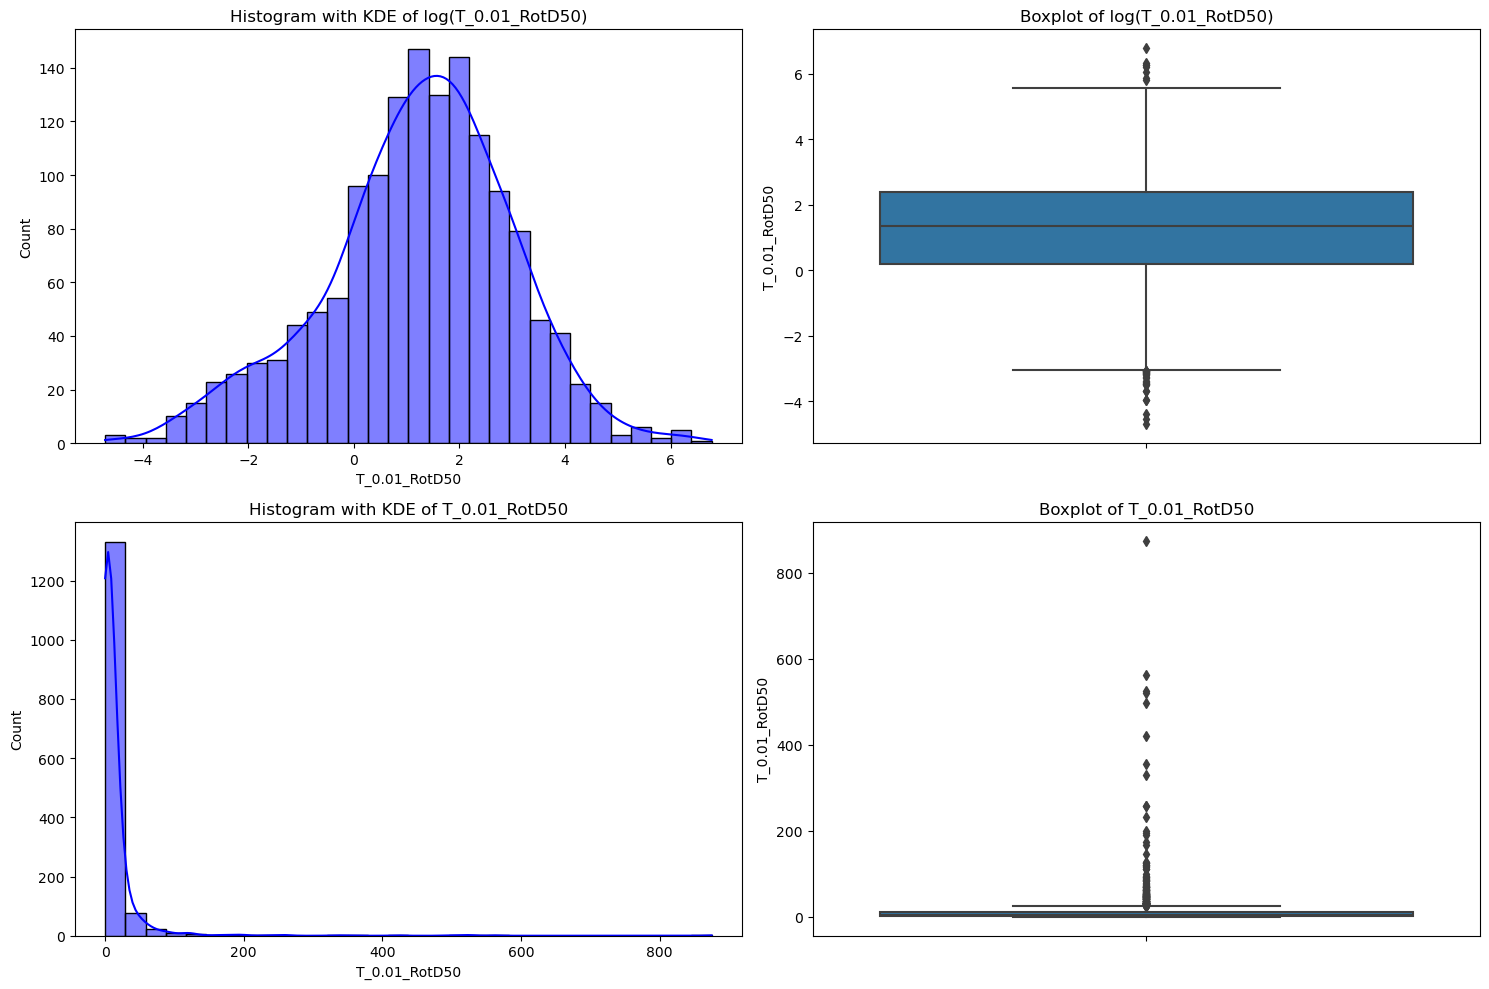

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # 2 filas, 3 columnas

sns.histplot(df_copy["T_0.01_RotD50"], kde=True, bins=30, color="blue", edgecolor="black", ax=axes[0][0])
axes[0][0].set_title("Histogram with KDE of log(T_0.01_RotD50)")

##stats.probplot(df_copy["T_0.01_RotD50"], dist="norm", plot=axes[0][1])
##axes[0][1].set_title("Q-Q Plot of log(T_0.01_RotD50)")

sns.boxplot(y=df_copy["T_0.01_RotD50"], ax=axes[0][1])
axes[0][1].set_title("Boxplot of log(T_0.01_RotD50)")

sns.histplot(df["T_0.01_RotD50"], kde=True, bins=30, color="blue", edgecolor="black", ax=axes[1][0])
axes[1][0].set_title("Histogram with KDE of T_0.01_RotD50")

##stats.probplot(df["T_0.01_RotD50"], dist="norm", plot=axes[1][1])
##axes[1][1].set_title("Q-Q Plot of T_0.01_RotD50")

sns.boxplot(y=df["T_0.01_RotD50"], ax=axes[1][1])
axes[1][1].set_title("Boxplot of T_0.01_RotD50")

plt.tight_layout()
plt.show()

Se puede evidenciar como mejora notablemente la distribución de la variable.<br>
A su vez, se logra identificar que existen datos atípicos en ambos grupos de datos que podrían afectar en las distribuciones.<br>
A partir de este punto se trabajará con el logaritmo de la aceleración espectral<br>

Es importante mencionar que en estudios anteriores también se ha realizado la transformación usando logaritmo natural tal como lo describe esta ecuación extraída de 

$$
\ln(\text{Sa}_{\text{RotD50}}) = \theta_1 + f_{\text{mag}}(M)_{\text{GL}} + f_{\text{mag}}(M)_{\text{REG}} 
+ f_{\text{path}}(M,R)_{\text{GL}} + f_{\text{path}}(R)_{\text{REG}} 
+ f_{\text{soil}}(S_{\text{cat}}, P^*)_{\text{REG}} + f_{\text{FABA}} + f_{Z_{\text{hypo}}}
$$

Donde $\text{Sa}_{\text{RotD50}}$ es la aceleración espectral

- **Análisis univariado**<br>

    - **Asimetría**<br><br>

        **skew = 0**: Distribución simétrica <br>
        **skew > 0**: Distribuido hacia cola izquierda (sesgo positivo).<br>
        **skew < 0**: Distribuido hacia cola derecha (sesgo negativo).<br><br>

    - **Kurtosis**: Forma de la distribución<br><br>

        **kurtosis = 3 (Mesocúrtica)**: Distribución normal.<br>
        **kurtosis < 3 (Platicúrtica)**: Distribución con colas menos gruesas que la normal.<br>
        **kurtosis > 3 (leptocúrtica)**: Distribución con colas más gruesas que la normal y con mayores valores atípicos<br>

Column:  Hypocenter Depth (km)
Skew: 0.42
Kurtosis:  -1.47


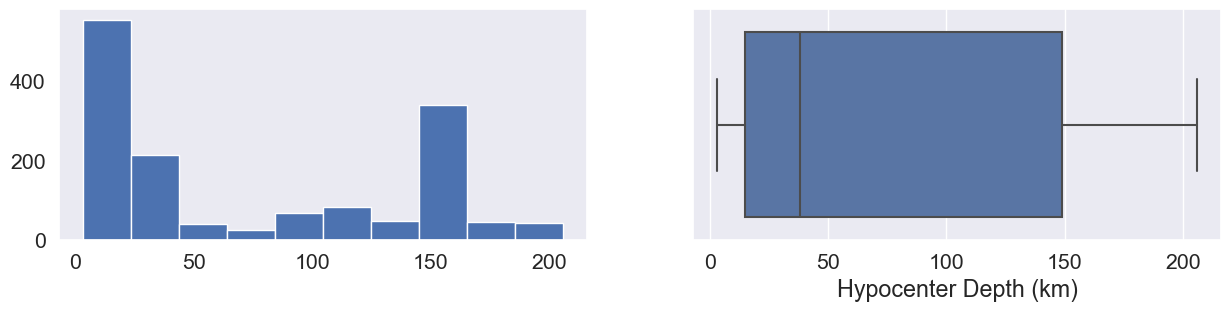

Column:  Magnitude
Skew: 1.06
Kurtosis:  0.33


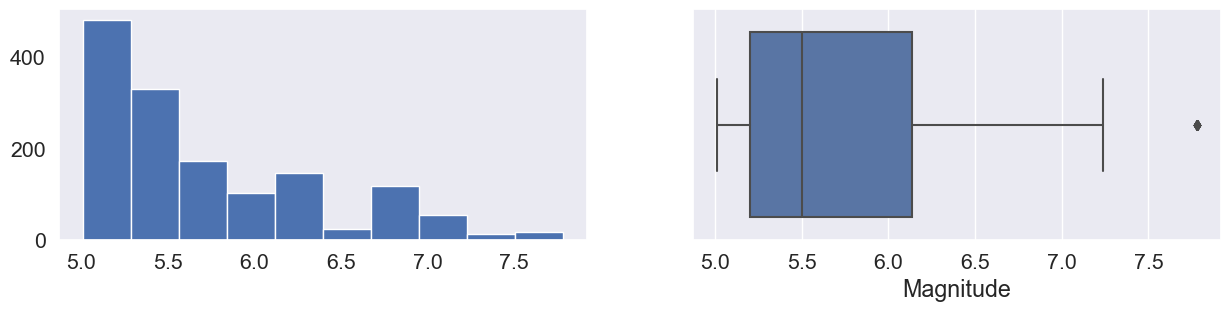

Column:  Nodal Plane 1 Strike (deg)
Skew: 0.13
Kurtosis:  -1.21


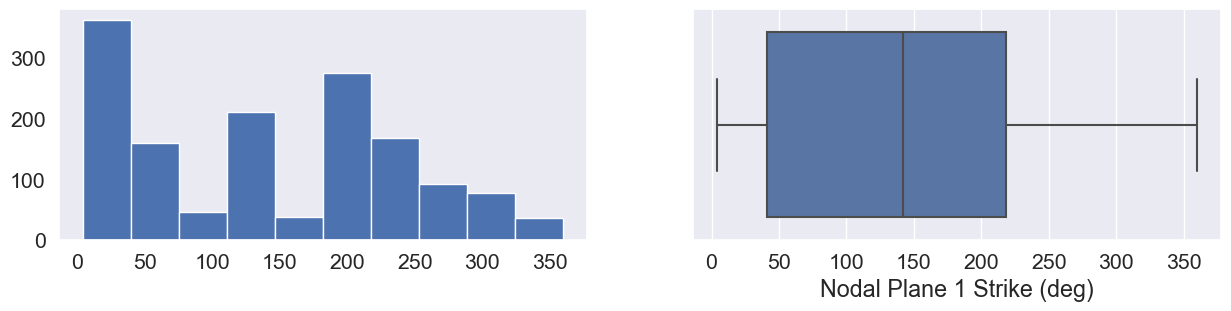

Column:  Nodal Plane 1 Dip (deg)
Skew: 0.16
Kurtosis:  -0.88


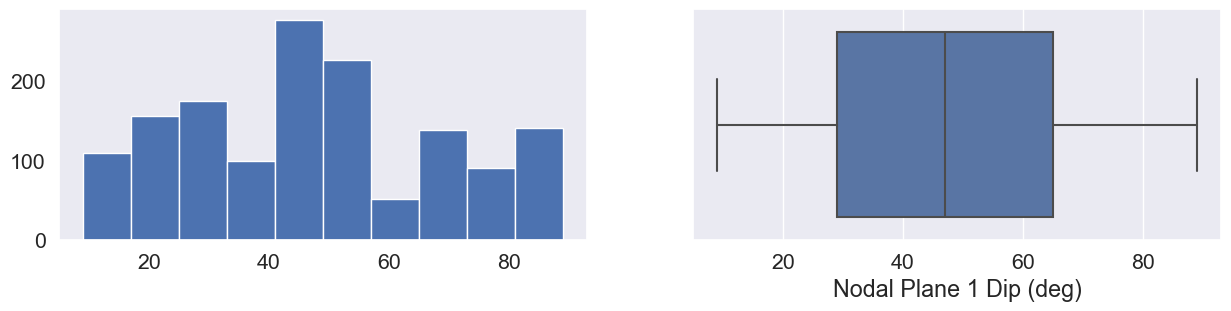

Column:  Nodal Plane 1 Rake Angle (deg)
Skew: -0.4
Kurtosis:  -1.22


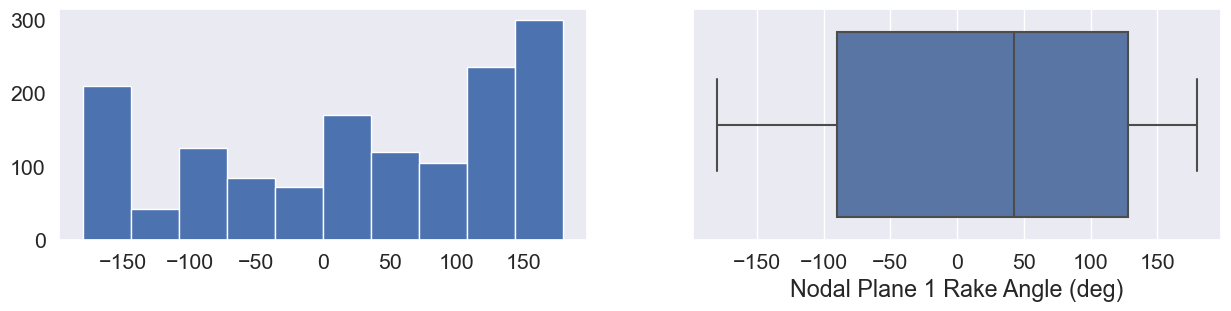

Column:  Nodal Plane 2 Strike (deg)
Skew: 0.22
Kurtosis:  -1.11


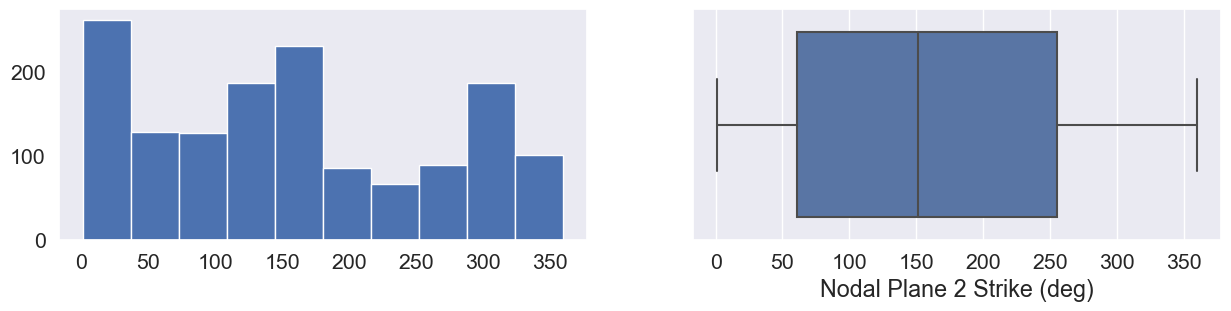

Column:  Nodal Plane 2 Dip (deg)
Skew: -0.3
Kurtosis:  -0.96


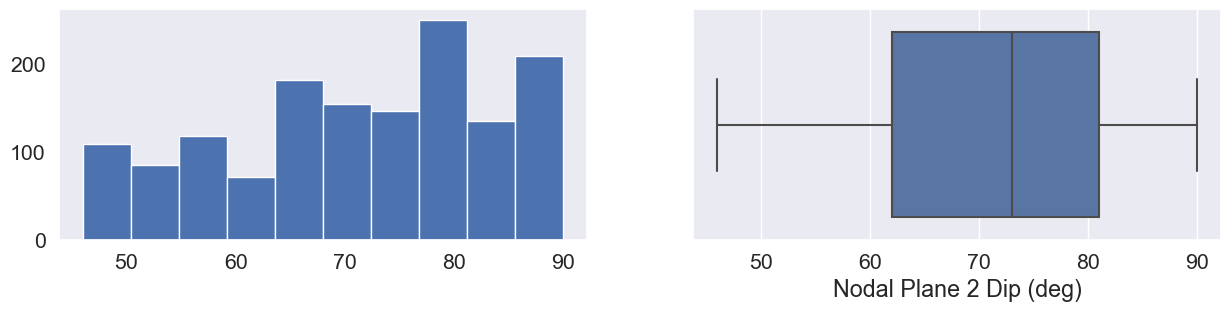

Column:  Nodal Plane 2 Rake Angle (deg)
Skew: -0.27
Kurtosis:  -0.9


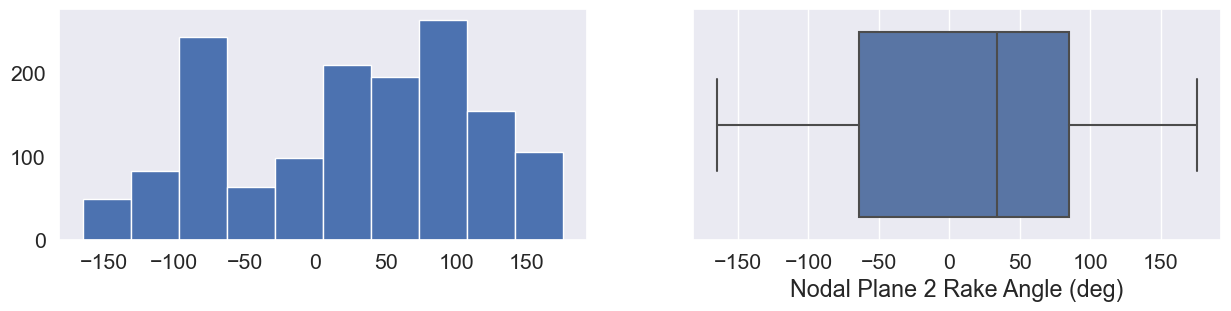

Column:  Station Elevation (m)
Skew: 0.54
Kurtosis:  -0.58


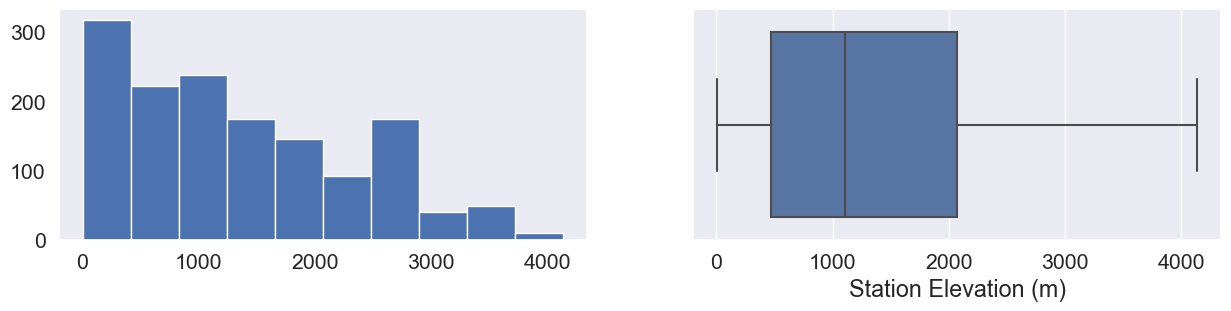

Column:  Repi_OpenQuake
Skew: 0.01
Kurtosis:  -1.0


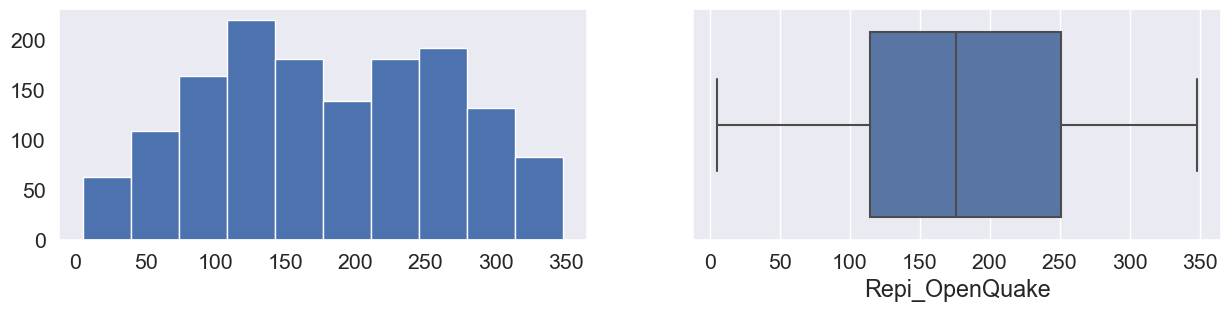

Column:  Rjb_OpenQuake
Skew: 0.03
Kurtosis:  -0.99


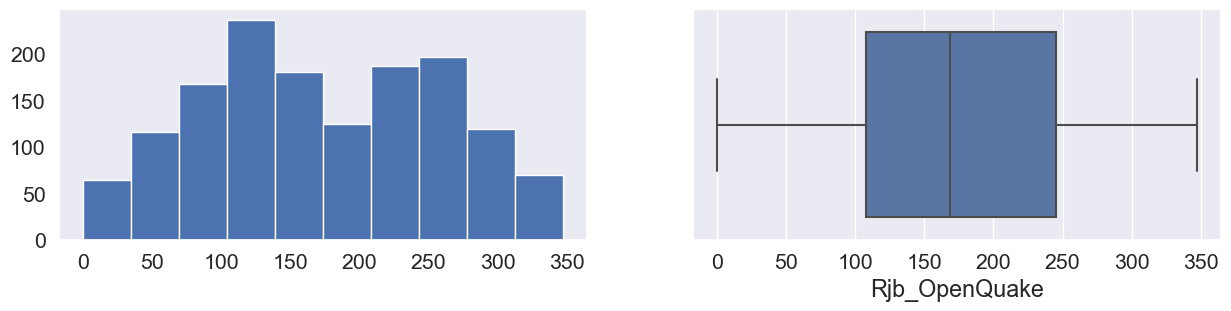

Column:  Rrup_OpenQuake
Skew: -0.1
Kurtosis:  -0.76


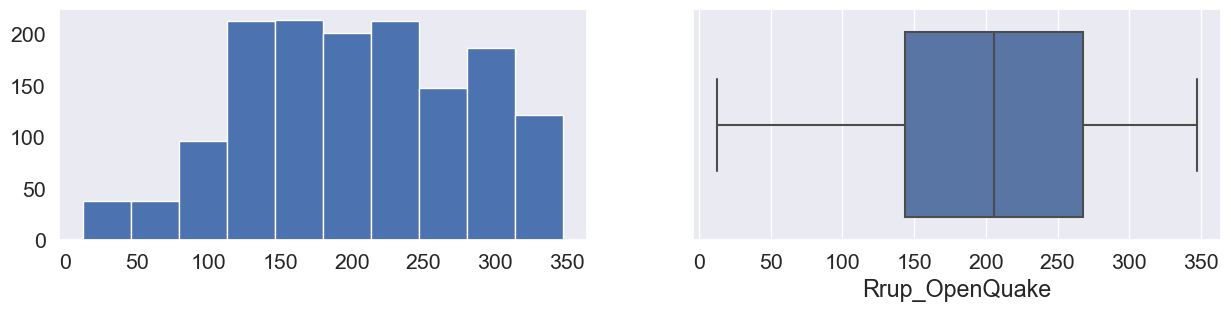

Column:  Rx_OpenQuake
Skew: -0.08
Kurtosis:  -0.39


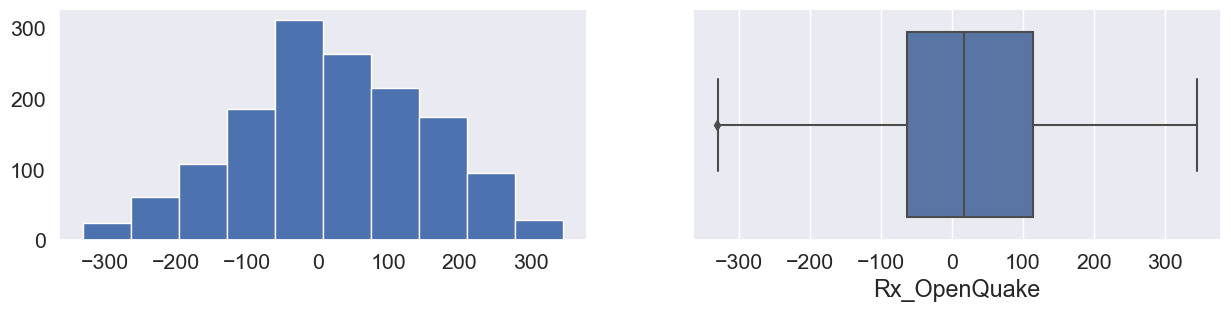

Column:  Rhypo_OpenQuake
Skew: -0.11
Kurtosis:  -0.79


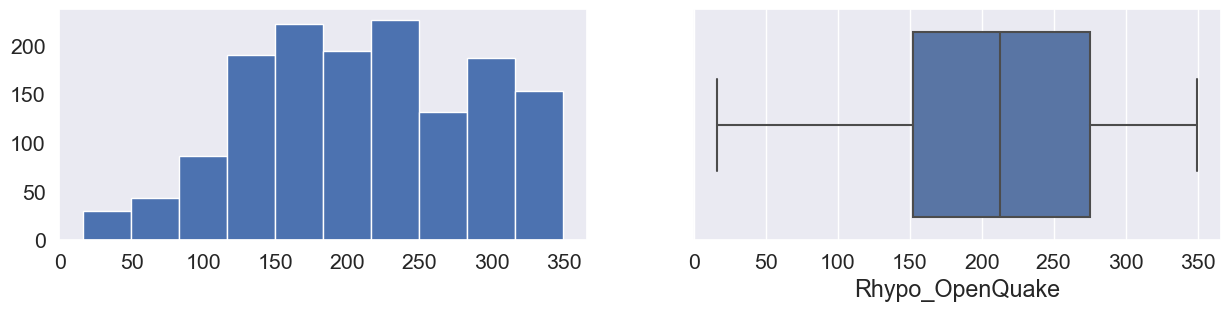

Column:  Ry0_OpenQuake
Skew: 0.59
Kurtosis:  -0.67


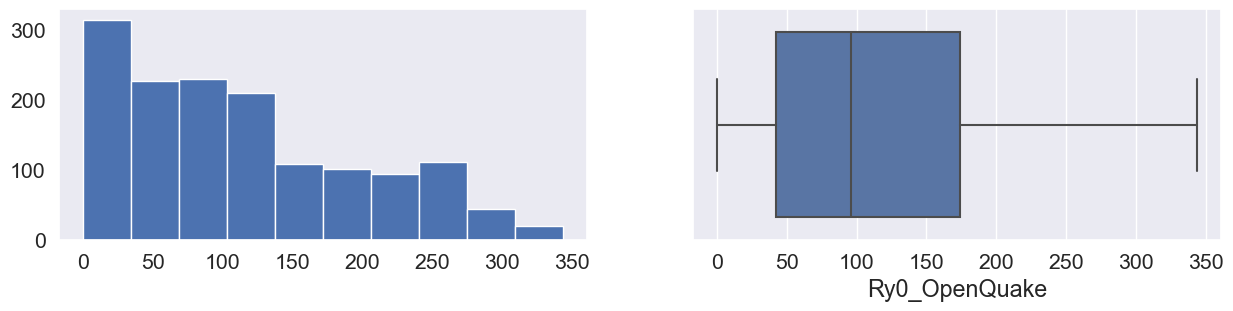

Column:  T_0.01_RotD50
Skew: -0.35
Kurtosis:  0.27


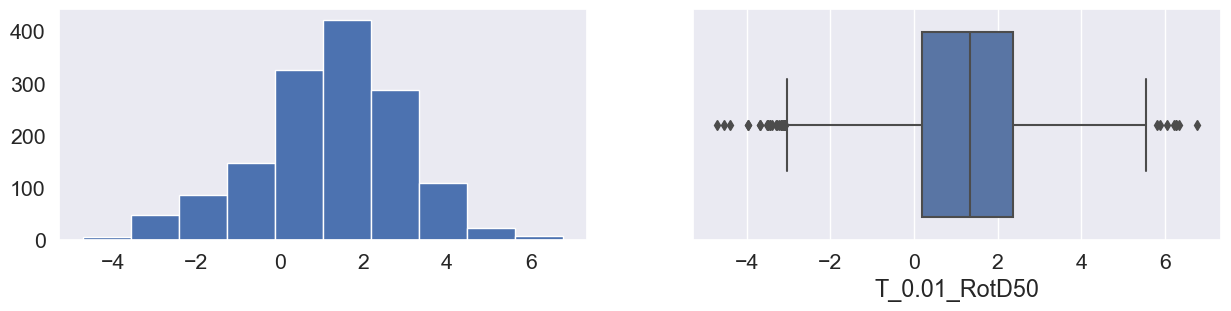

In [19]:
sns.set(font_scale=1.4)
num_cols = df_copy.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("Fault Plane (1; 2; X)")
for col in num_cols:
    print('Column: ', col)
    print('Skew:', round(df_copy[col].skew(), 2))
    print('Kurtosis: ', round(df_copy[col].kurtosis(), 2))
    plt.figure(figsize = (15, 3))
    plt.subplot(1, 2, 1)
    df_copy[col].hist(grid=False)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_copy[col])
    plt.show()

In [20]:

from scipy.stats import kstest, norm

def kolmogorov_smirnov_test(df, columns=None):
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
        columns.remove("Fault Plane (1; 2; X)")
    p_values =[]
    results = []
    names =[]
    for col in columns:
        data = df[col].dropna()
        if len(data) > 1:
            # Normalizar
            standardized_data = (data - data.mean()) / data.std()
            ks_stat, p_value = kstest(standardized_data, 'norm', args=(0, 1))
            results.append({'Variable': col, 'KS Statistic': ks_stat, 'p-value': p_value})
            names.append(col)
            p_values.append(p_value)
    
    return pd.DataFrame(results),names,p_values

resultado,nombres,pvalores = kolmogorov_smirnov_test(df_copy)
print(resultado)

                          Variable  KS Statistic       p-value
0            Hypocenter Depth (km)      0.228823  7.329973e-68
1                        Magnitude      0.172232  1.917698e-38
2       Nodal Plane 1 Strike (deg)      0.156246  1.111651e-31
3          Nodal Plane 1 Dip (deg)      0.071911  4.986788e-07
4   Nodal Plane 1 Rake Angle (deg)      0.140858  8.345281e-26
5       Nodal Plane 2 Strike (deg)      0.089718  1.053501e-10
6          Nodal Plane 2 Dip (deg)      0.088649  1.845820e-10
7   Nodal Plane 2 Rake Angle (deg)      0.097560  1.398780e-12
8            Station Elevation (m)      0.103792  3.476675e-14
9                   Repi_OpenQuake      0.061385  3.078739e-05
10                   Rjb_OpenQuake      0.066581  4.364239e-06
11                  Rrup_OpenQuake      0.051215  8.898537e-04
12                    Rx_OpenQuake      0.023586  3.834264e-01
13                 Rhypo_OpenQuake      0.055525  2.303643e-04
14                   Ry0_OpenQuake      0.093149  1.662

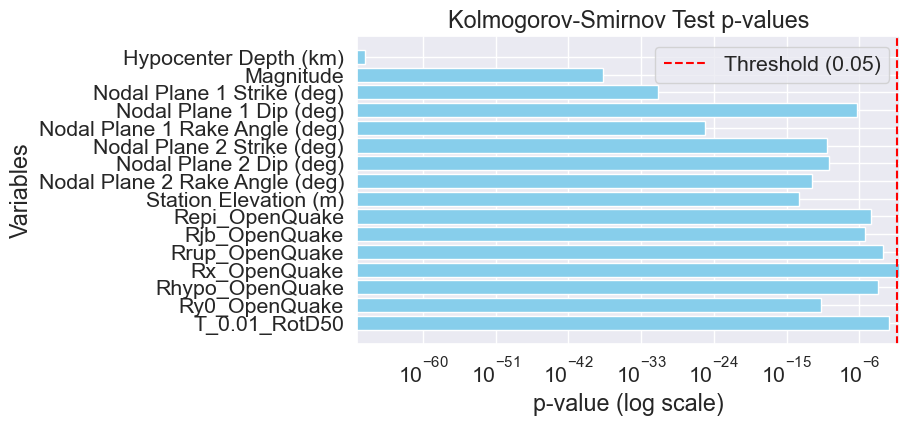

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_p_values(names, p_values):
    
    plt.figure(figsize=(7, 4))
    plt.barh(names, p_values, color='skyblue')
    plt.axvline(x=0.05, color='red', linestyle='--', label='Threshold (0.05)')
    
    plt.xlabel('p-value (log scale)')
    plt.ylabel('Variables')
    plt.title('Kolmogorov-Smirnov Test p-values')
    
    plt.xscale('log')  # escala log
    plt.xlim([min(p_values) * 0.1, 0.1])  # limites
    
    plt.gca().invert_yaxis() 
    plt.legend()
    plt.show()


plot_p_values(nombres, pvalores)


### 1.1.2 Variables Categóricas

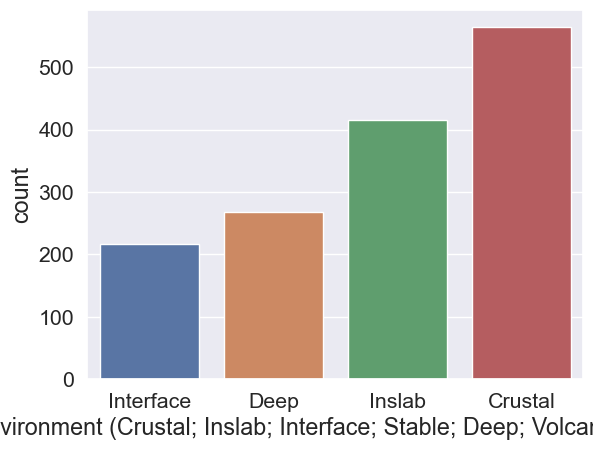

In [22]:
sns.countplot(x=df_copy["Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"])
plt.show()

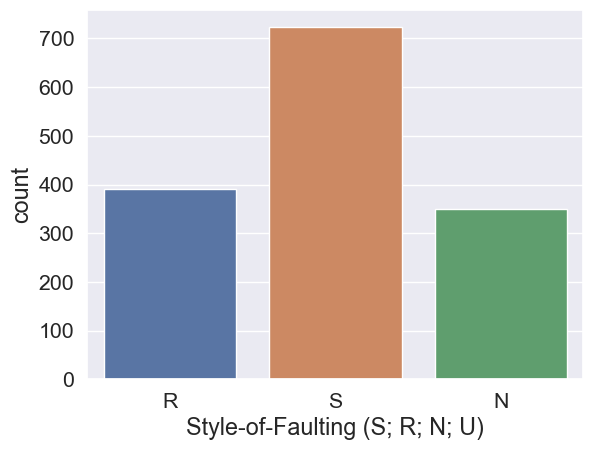

In [23]:
sns.countplot(x=df_copy["Style-of-Faulting (S; R; N; U)"])
plt.show()

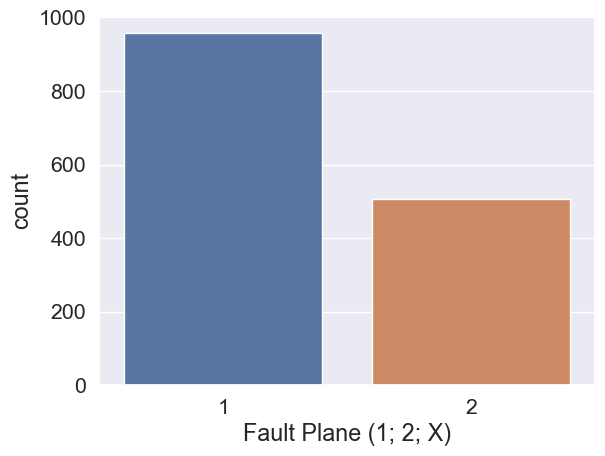

In [24]:
sns.countplot(x=df_copy["Fault Plane (1; 2; X)"])
plt.show()

## 1.2. Análisis Bivariado 

### 1.2.1 Variables Numéricas

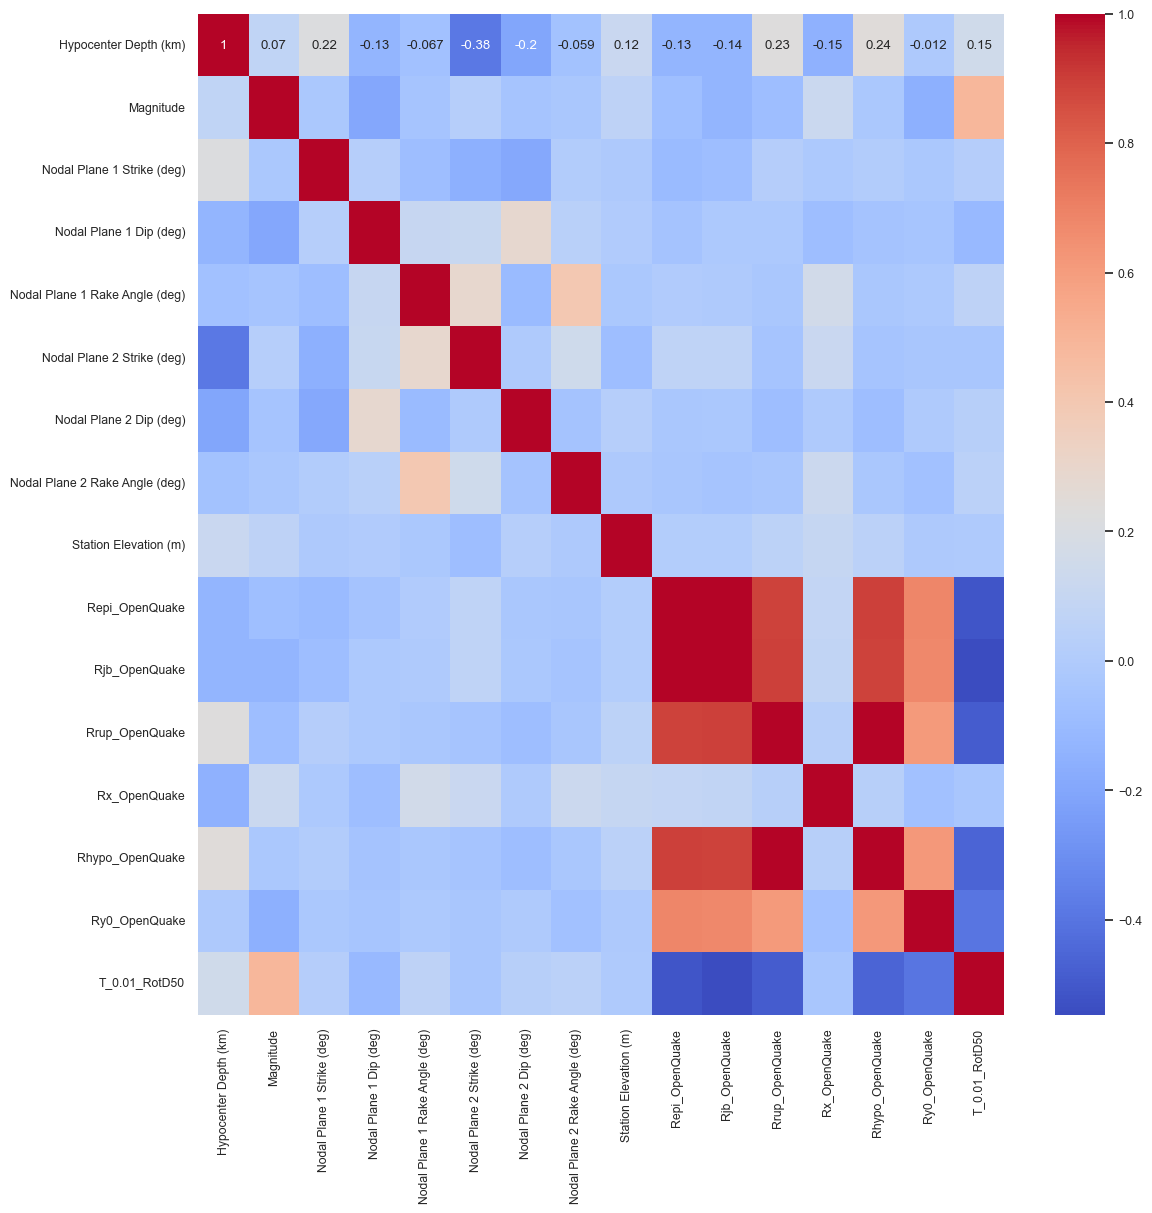

In [25]:
# columnas numericas
df_numerico = df_copy.select_dtypes(include=[float, int])


sns.set(font_scale=0.8)
plt.figure(figsize=(13,13))

# Spearman con mapa
sns.heatmap(df_numerico.drop(columns=["Fault Plane (1; 2; X)"], errors="ignore").corr(method="spearman"), annot=True, cmap='coolwarm')

plt.show()

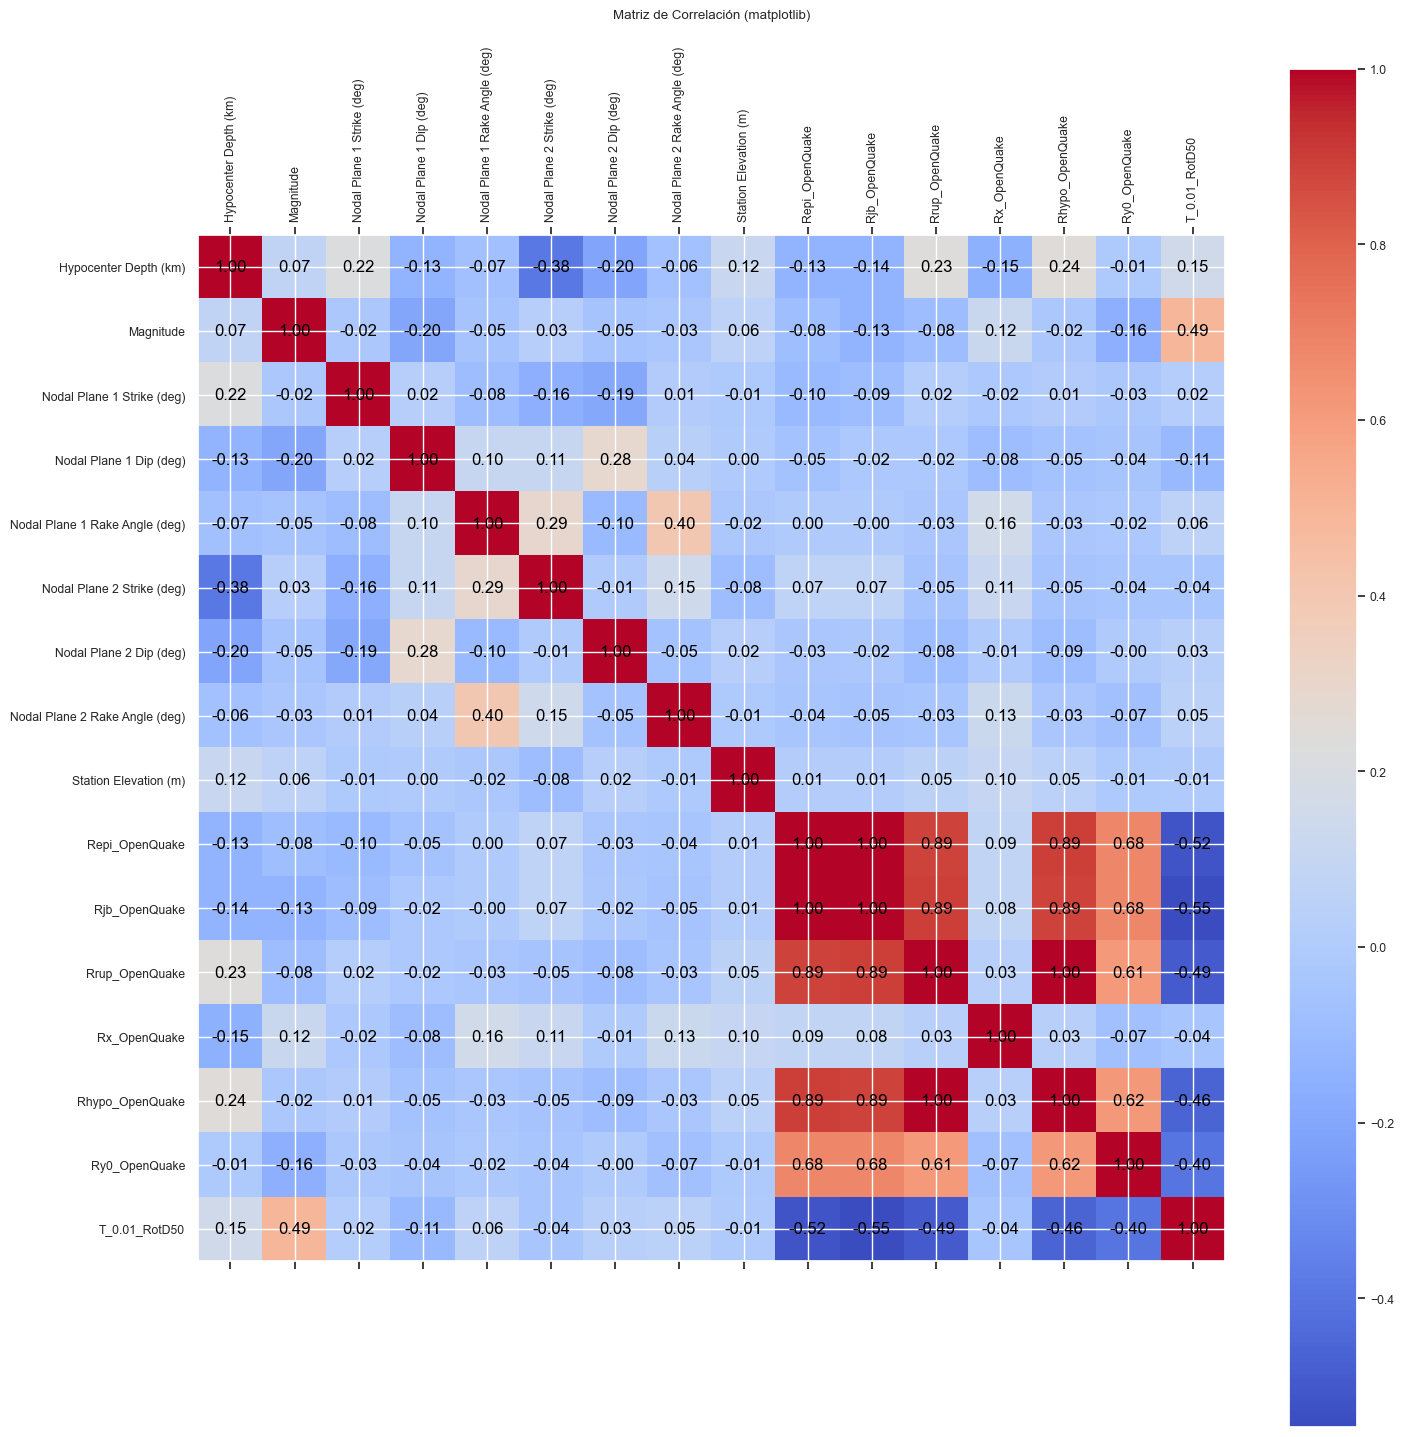

In [26]:
corr_matrix = df_numerico.drop(columns=["Fault Plane (1; 2; X)"], errors="ignore").corr(method="spearman")
labels = corr_matrix.columns.tolist()
fig, ax = plt.subplots(figsize=(15, 15))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

for (i, j), val in np.ndenumerate(corr_matrix.values):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=12)

plt.title("Matriz de Correlación (matplotlib)", pad=20)
plt.tight_layout()
plt.show()


In [45]:
corr_matrix = df_numerico.drop(columns=["Fault Plane (1; 2; X)"], errors="ignore").corr(method="spearman")
corr_matrix["T_0.01_RotD50"].sort_values(ascending=False)

T_0.01_RotD50                     1.000000
Magnitude                         0.486602
Hypocenter Depth (km)             0.148316
Nodal Plane 1 Rake Angle (deg)    0.062739
Nodal Plane 2 Rake Angle (deg)    0.047805
Nodal Plane 2 Dip (deg)           0.032291
Nodal Plane 1 Strike (deg)        0.016266
Station Elevation (m)            -0.007398
Nodal Plane 2 Strike (deg)       -0.036097
Rx_OpenQuake                     -0.037893
Nodal Plane 1 Dip (deg)          -0.108673
Ry0_OpenQuake                    -0.399104
Rhypo_OpenQuake                  -0.456044
Rrup_OpenQuake                   -0.490370
Repi_OpenQuake                   -0.515252
Rjb_OpenQuake                    -0.546566
Name: T_0.01_RotD50, dtype: float64

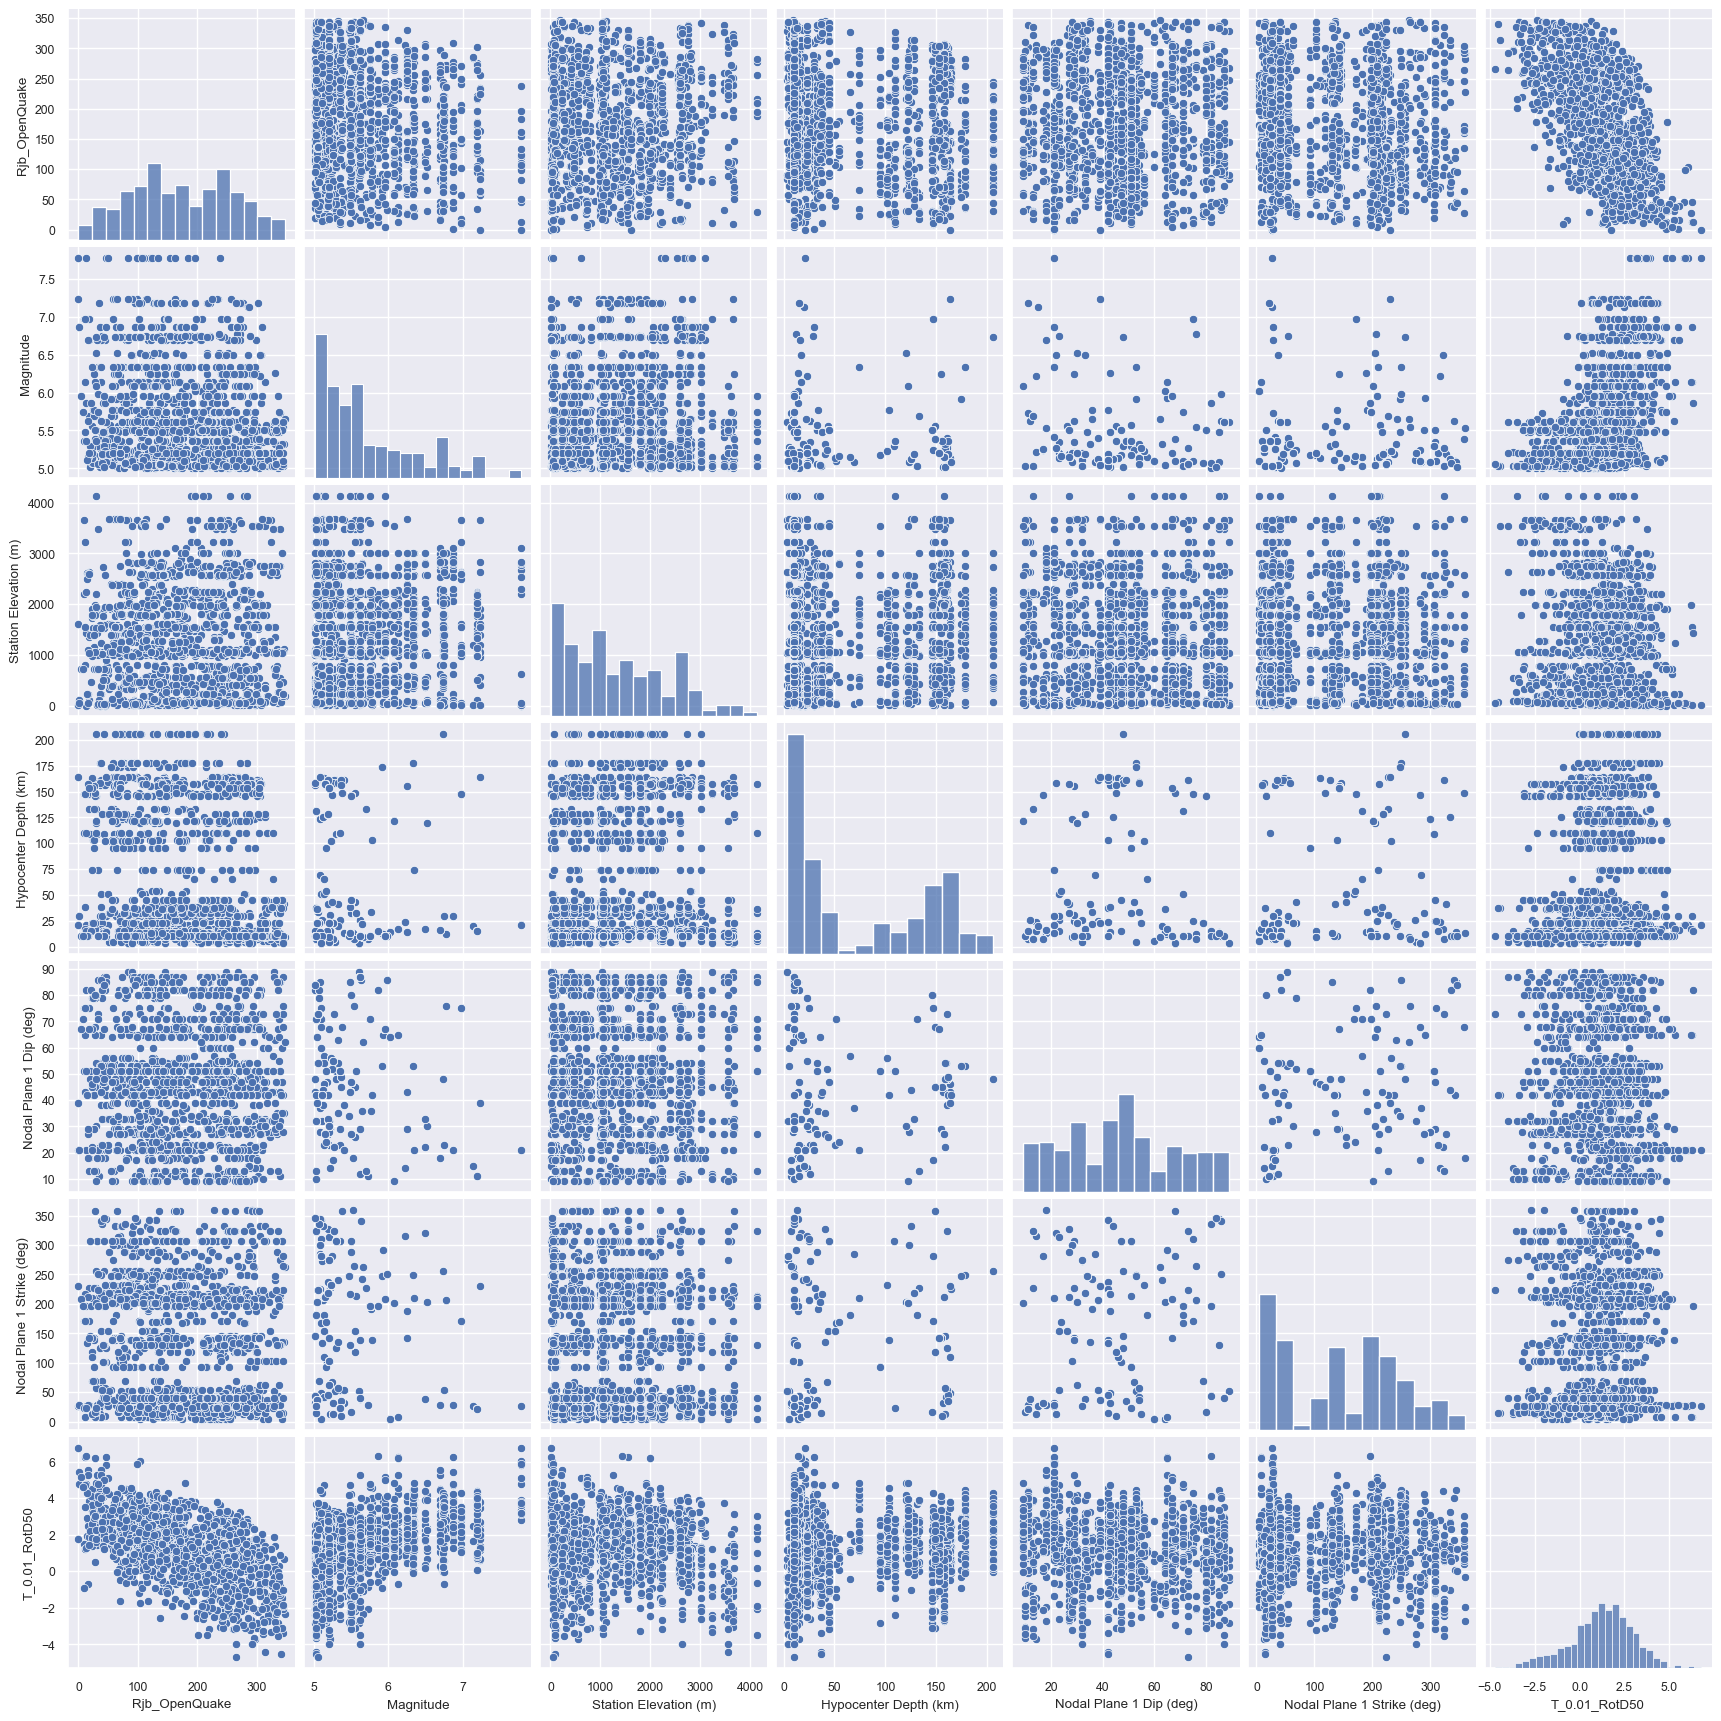

In [28]:


# Filtrar solo variables seleccionadas
selected_vars = ["Rjb_OpenQuake", "Magnitude", "Station Elevation (m)", "Hypocenter Depth (km)","Nodal Plane 1 Dip (deg)","Nodal Plane 1 Strike (deg)" ,"T_0.01_RotD50"]
sns.pairplot(df_copy[selected_vars])
plt.show()


### 1.1.2 Variables Categóricas con variable de respuesta

In [29]:
variable_respuesta = "T_0.01_RotD50"
variables_categoricas = ["Fault Plane (1; 2; X)", 
                         "Style-of-Faulting (S; R; N; U)", 
                         "Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"]

# Iterar sobre cada variable categórica y aplicar la prueba de Kruskal-Wallis
for var in variables_categoricas:
    print(f"\n {var} and {variable_respuesta}")
    
    groups = [df_copy[df_copy[var] == cat][variable_respuesta] for cat in df_copy[var].unique()]
    
    kruskal_stat, p_value = stats.kruskal(*groups)
    
    print(f"Kruskal-Wallis H: {kruskal_stat:.3f}, p-valor: {p_value:.5f}")



 Fault Plane (1; 2; X) and T_0.01_RotD50
Kruskal-Wallis H: 0.858, p-valor: 0.35420

 Style-of-Faulting (S; R; N; U) and T_0.01_RotD50
Kruskal-Wallis H: 19.205, p-valor: 0.00007

 Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust) and T_0.01_RotD50
Kruskal-Wallis H: 12.147, p-valor: 0.00690


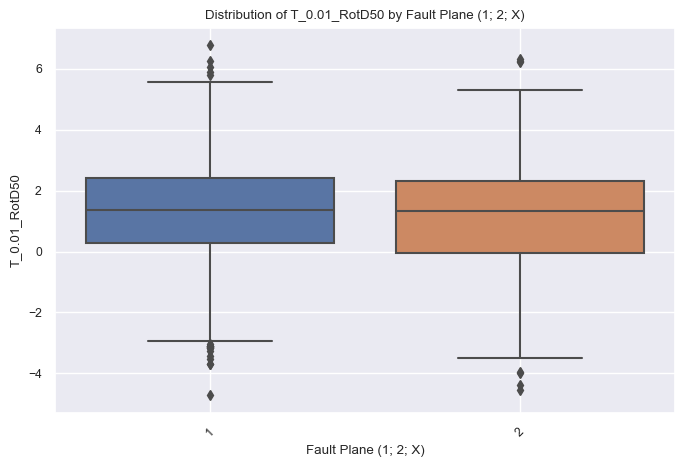

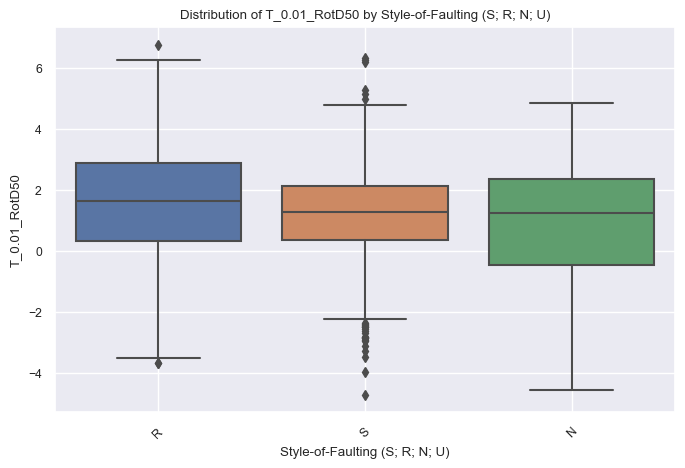

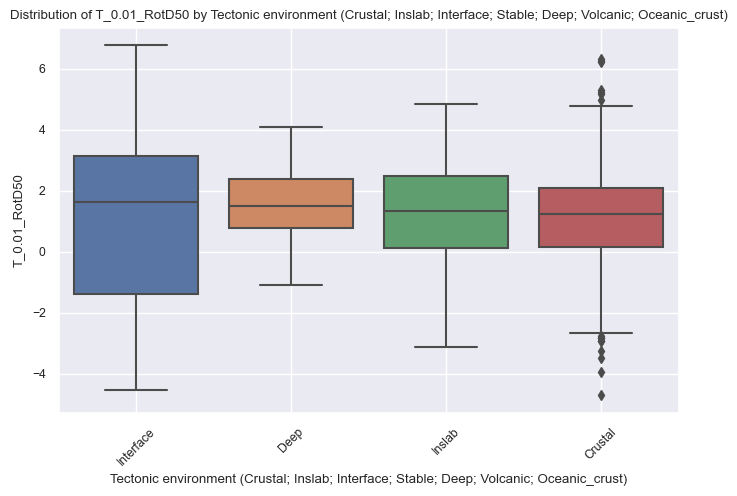

In [30]:

variable_respuesta = "T_0.01_RotD50"

variables_categoricas = ["Fault Plane (1; 2; X)", 
                         "Style-of-Faulting (S; R; N; U)", 
                         "Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"]


for var in variables_categoricas:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=var, y=variable_respuesta, data=df_copy)
    plt.title(f"Distribution of {variable_respuesta} by {var}")
    plt.xlabel(var)
    plt.ylabel(variable_respuesta)
    plt.xticks(rotation=45)  
    plt.grid(True)
    plt.show()

In [31]:
import scikit_posthocs as sp


# Iterar sobre cada variable categórica
for var in variables_categoricas:
    print(f"\n post-hoc for {var}")

    #Kruskal-Wallis
    H, p = stats.kruskal(*[df_copy[df_copy[var] == cat][variable_respuesta].dropna() 
                            for cat in df_copy[var].unique()])
    
    print(f"Kruskal-Wallis H: {H:.4f}, p-valor: {p:.5f}")

    #Si hay diferencias significativas, aplicar la prueba de Dunn con corrección de Bonferroni
    if p < 0.05:
        dunn_test = sp.posthoc_dunn(df_copy, val_col=variable_respuesta, group_col=var, p_adjust="bonferroni")
        print("\n Dunn's test with Bonferroni's correction:")
        print(dunn_test)
    else:
        print("No significative diferences")



 post-hoc for Fault Plane (1; 2; X)
Kruskal-Wallis H: 0.8583, p-valor: 0.35420
No significative diferences

 post-hoc for Style-of-Faulting (S; R; N; U)
Kruskal-Wallis H: 19.2049, p-valor: 0.00007

 Dunn's test with Bonferroni's correction:
          N         R         S
N  1.000000  0.000158  0.877393
R  0.000158  1.000000  0.000796
S  0.877393  0.000796  1.000000

 post-hoc for Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)
Kruskal-Wallis H: 12.1468, p-valor: 0.00690

 Dunn's test with Bonferroni's correction:
            Crustal      Deep    Inslab  Interface
Crustal    1.000000  0.002993  0.970335   1.000000
Deep       0.002993  1.000000  0.192672   0.430915
Inslab     0.970335  0.192672  1.000000   1.000000
Interface  1.000000  0.430915  1.000000   1.000000


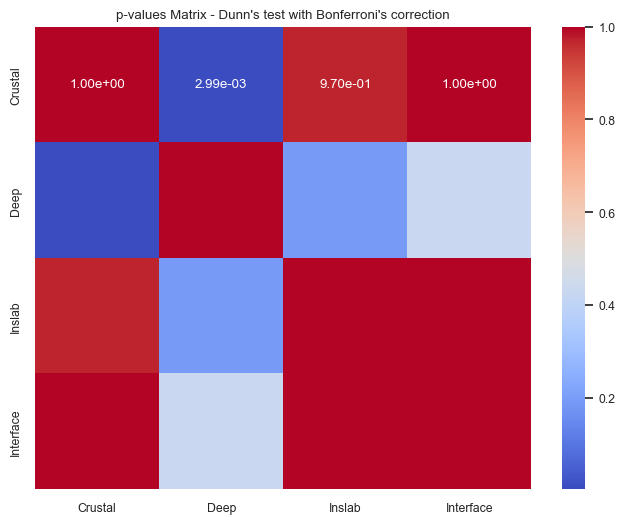

In [32]:

# Aplicar la prueba de Dunn con corrección de Bonferroni
dunn_test = sp.posthoc_dunn(df, val_col="T_0.01_RotD50", group_col="Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)", p_adjust="bonferroni")
plt.figure(figsize=(8, 6))
sns.heatmap(dunn_test, annot=True, fmt=".2e", cmap="coolwarm", xticklabels=dunn_test.columns, yticklabels=dunn_test.index)
plt.title("p-values Matrix - Dunn's test with Bonferroni's correction")
plt.show()

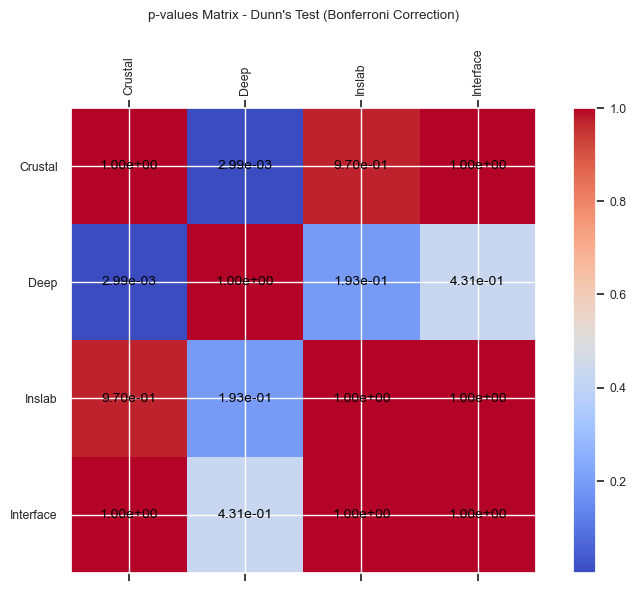

In [33]:

dunn_test = dunn_test.astype(float)

vals = dunn_test.values
labels = dunn_test.columns.tolist()

fig, ax = plt.subplots(figsize=(8, 6))

cax = ax.matshow(vals, cmap='coolwarm')

fig.colorbar(cax)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

for (i, j), val in np.ndenumerate(vals):
    text = f"{val:.2e}" if not np.isnan(val) else ""
    ax.text(j, i, text, va='center', ha='center', color='black', fontsize=10)

plt.title("p-values Matrix - Dunn's Test (Bonferroni Correction)", pad=20)
plt.tight_layout()
plt.show()


There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)

### A


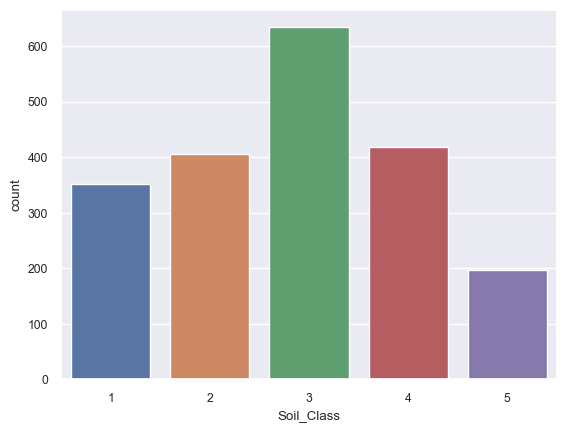

In [34]:
sns.countplot(x=df2["Soil_Class"])
plt.show()

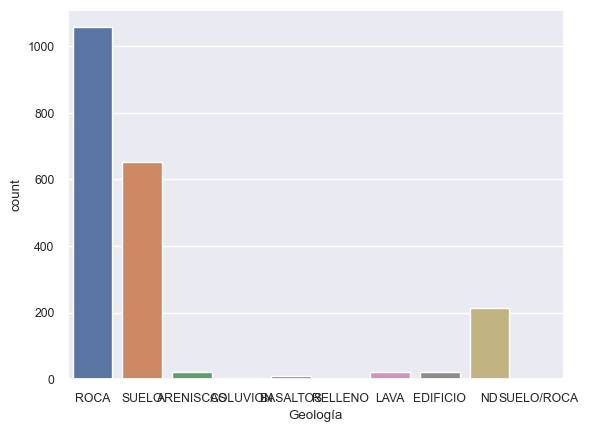

In [35]:
sns.countplot(x=df2["Geología"])
plt.show()

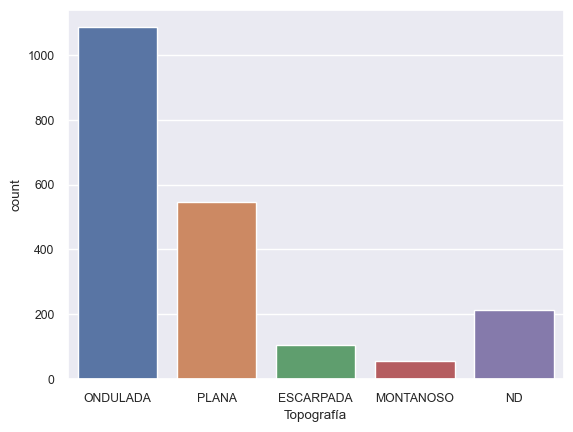

In [36]:
sns.countplot(x=df2["Topografía"])
plt.show()

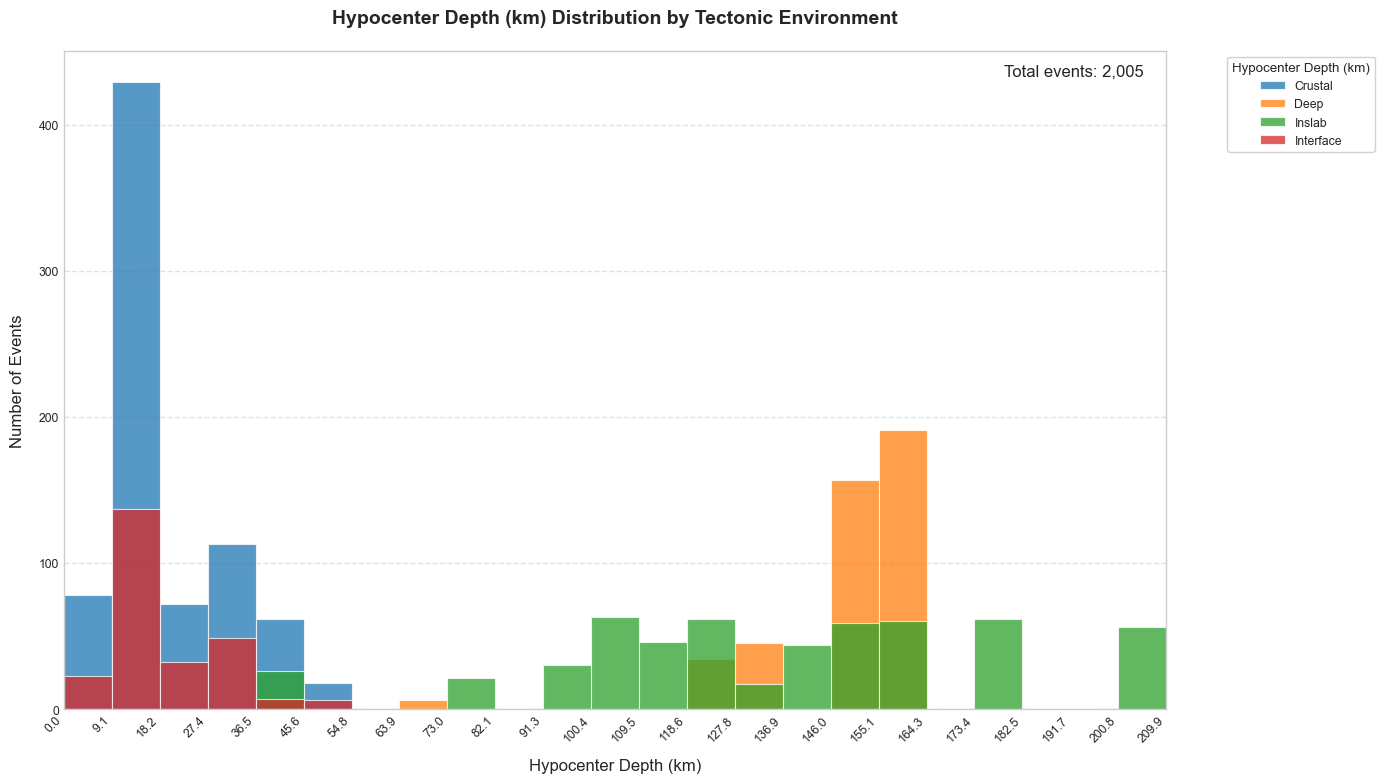

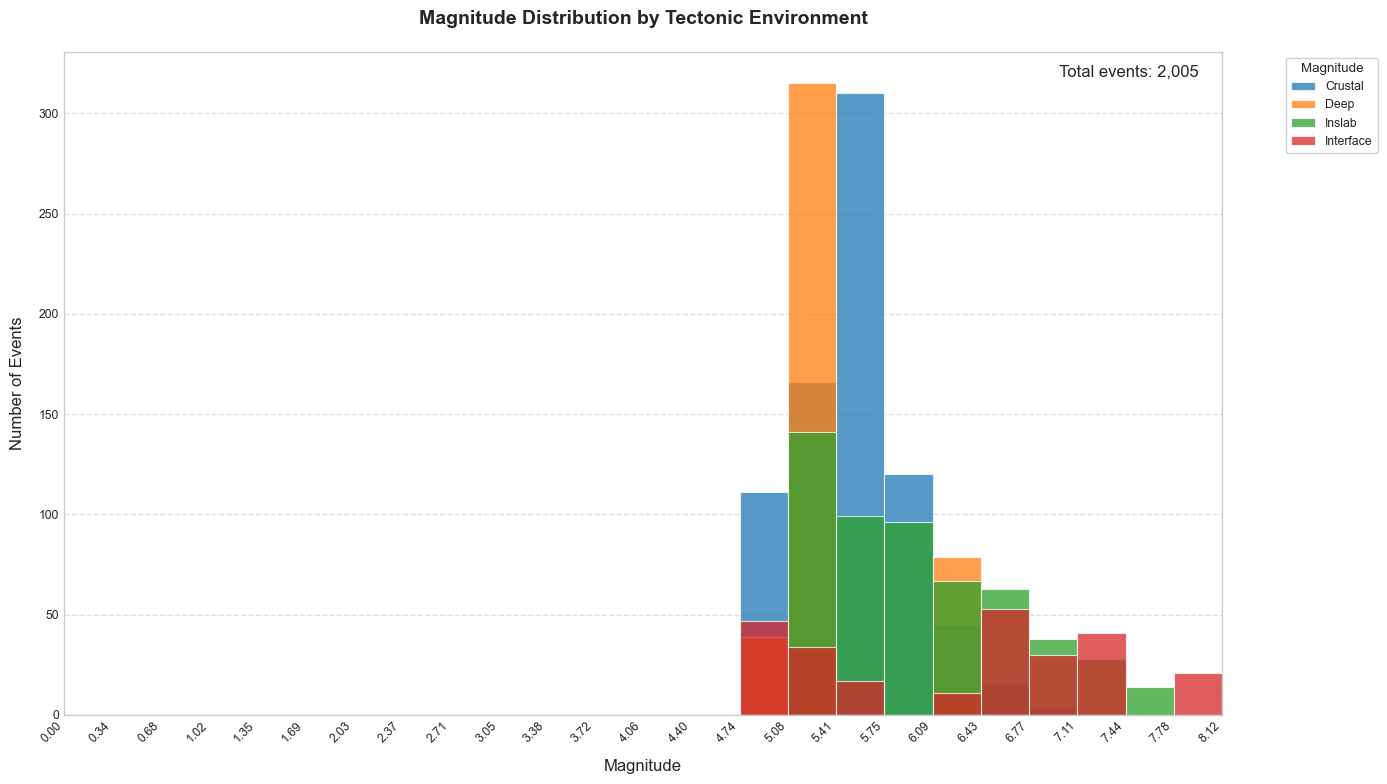

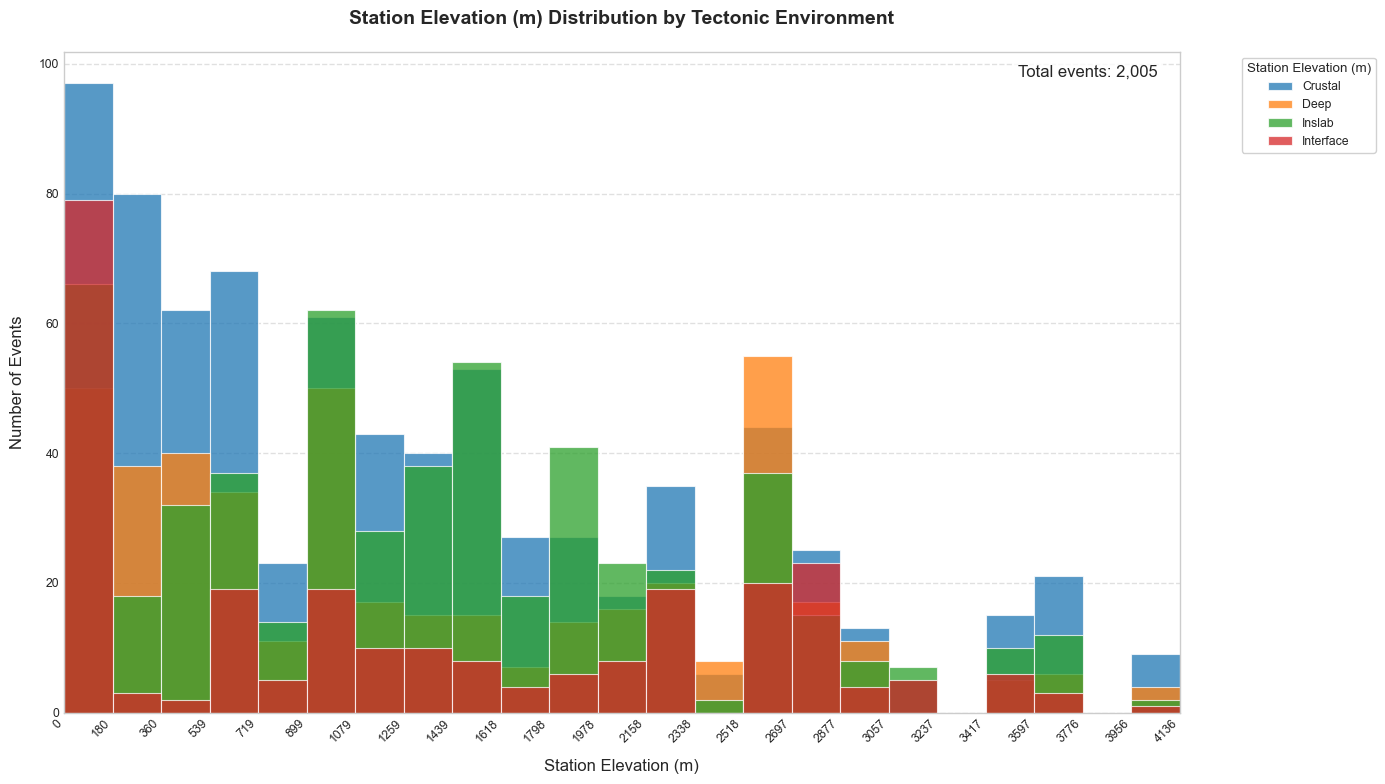

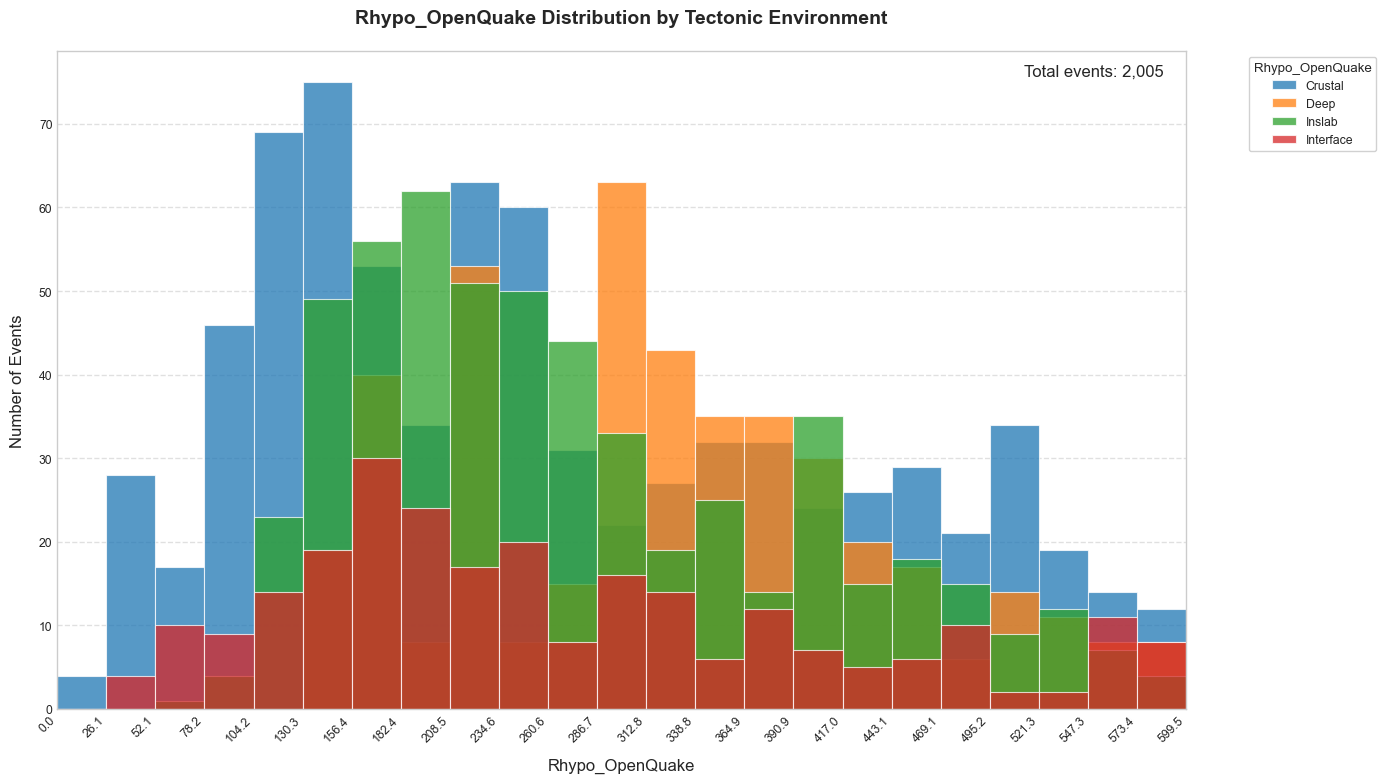

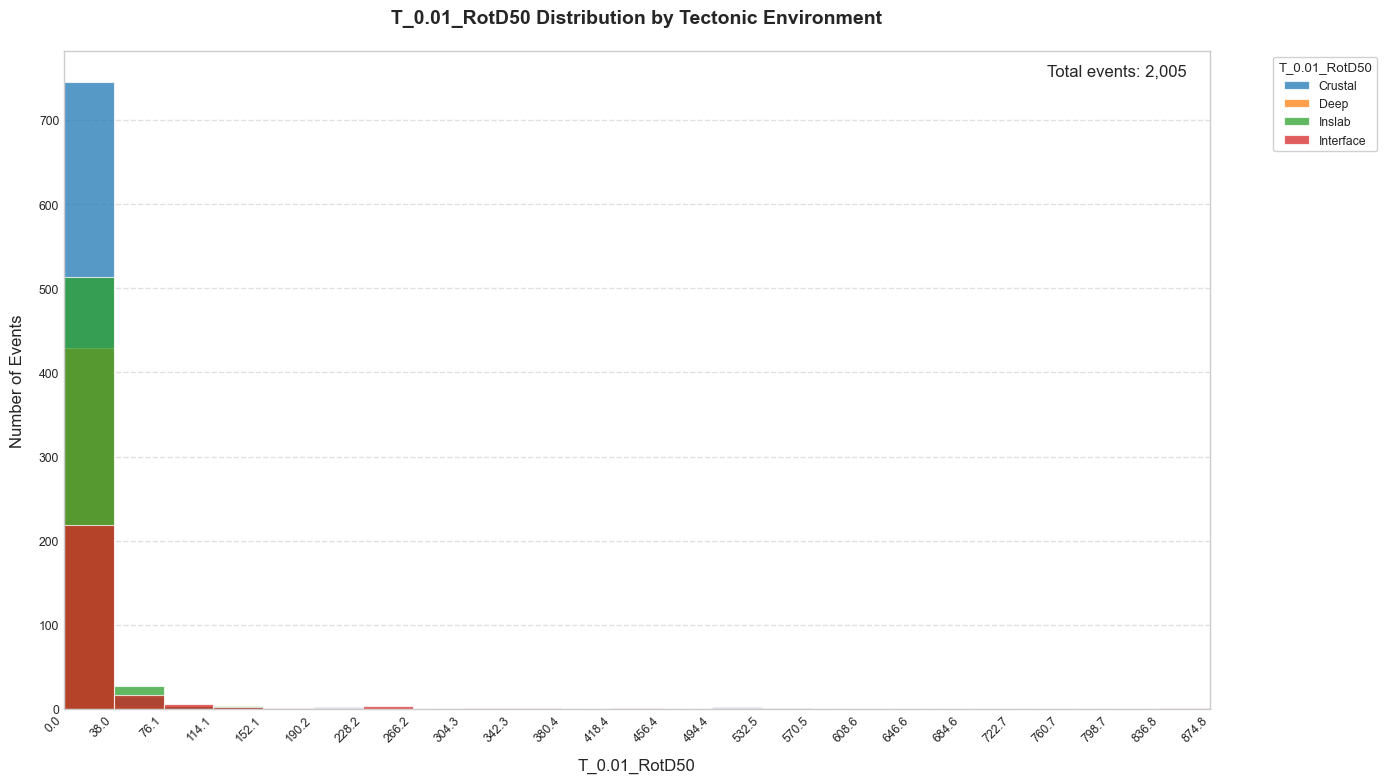

In [37]:
lista = ["Hypocenter Depth (km)", "Magnitude", "Station Elevation (m)", "Rhypo_OpenQuake","T_0.01_RotD50"]

for variable in lista:
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14

    fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

    # Bin width adaptado al caso
    if variable == "Tn":
        bin_width = 0.05  # Puedes ajustar a 0.1 si prefieres menos barras
    else:
        bin_width = df2[variable].max() / 23

    # Calcular máximo ajustado al último bin exacto sin pasar del valor máximo
    max_val = df2[variable].max()
    max_depth = np.ceil(max_val / bin_width) * bin_width

    # Asegurar que el bin superior incluya el valor máximo
    bins = np.arange(0, max_depth + bin_width, bin_width)
    bins = bins[bins <= max_val + bin_width]  # Evitar bin vacío final

    # Tectonic environments y colores
    tectonic_envs = df2["Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"].unique()
    colors = plt.cm.tab10.colors

    # Histograma apilado
    for i, env in enumerate(tectonic_envs):
        subset = df2[df2["Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"] == env]
        plt.hist(
            subset[variable].dropna(),
            bins=bins,
            color=colors[i % len(colors)],
            edgecolor='white',
            linewidth=0.8,
            alpha=0.75,
            label=env
        )

    # Etiquetas del eje X limpias y redondeadas
    ax.set_xticks(bins)
    ax.set_xlim([0, bins[-1]])  # Ajustar al último bin útil
    plt.xticks(np.round(bins, 2), rotation=45, ha='right')

    # Títulos y ejes
    plt.title(f"{variable} Distribution by Tectonic Environment", pad=20, fontweight='bold')
    plt.xlabel(f"{variable}", labelpad=10)
    plt.ylabel("Number of Events", labelpad=10)

    # Leyenda
    plt.legend(
        title=f"{variable}",
        frameon=True,
        framealpha=0.9,
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    # Rejilla y anotaciones
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.xaxis.grid(False)

    total_events = len(df2[variable].dropna())
    plt.annotate(
        f"Total events: {total_events:,}",
        xy=(0.98, 0.98),
        xycoords='axes fraction',
        ha='right',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.tight_layout()
    plt.show()


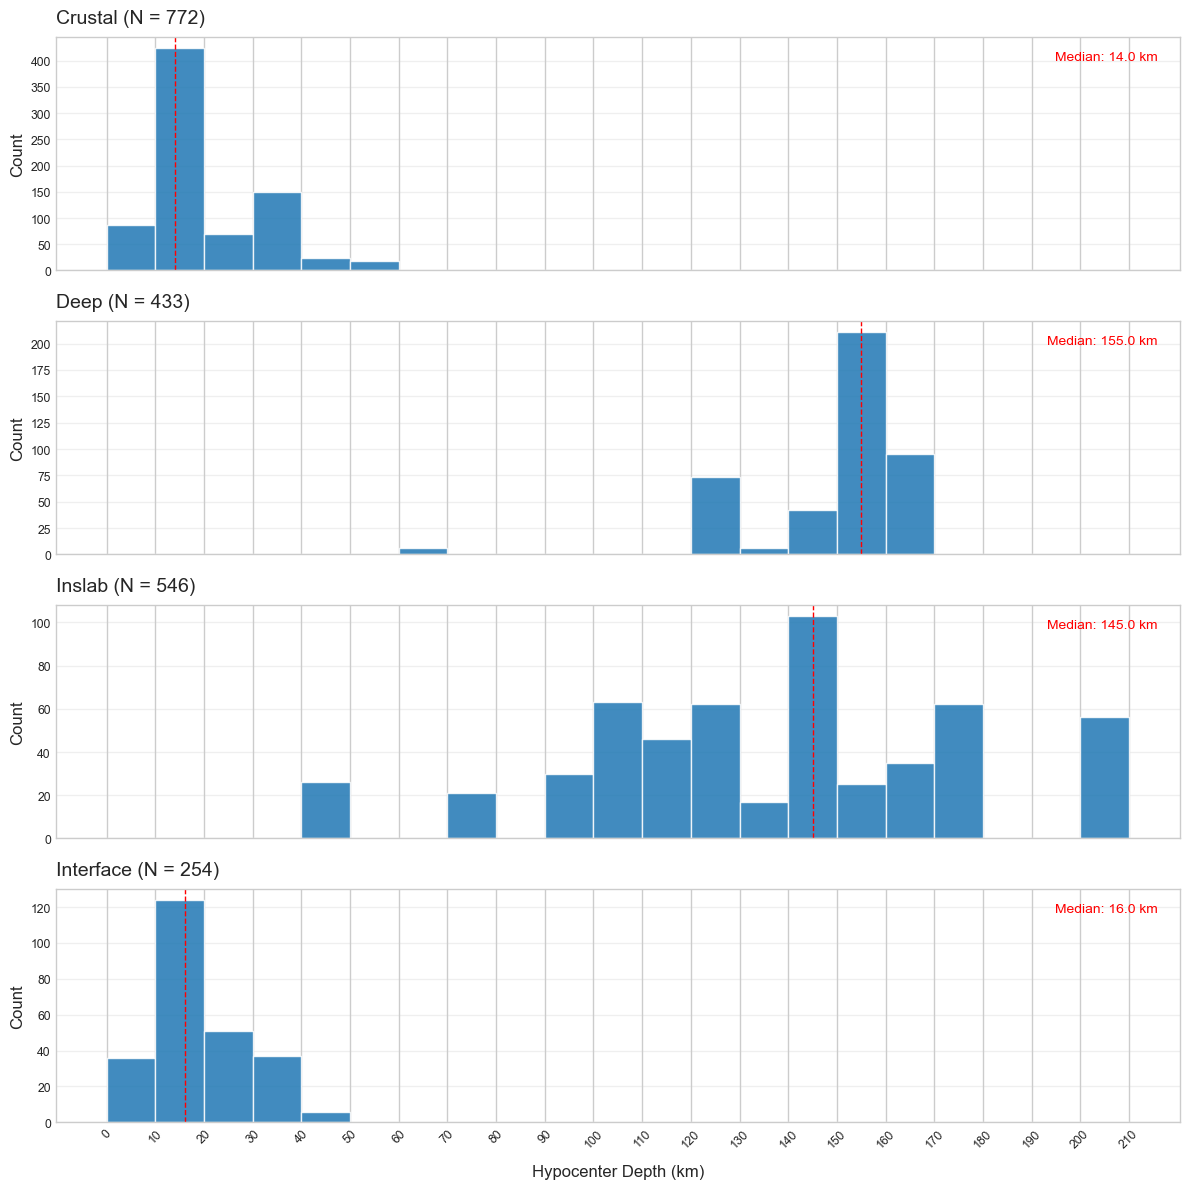

In [38]:
# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10

# Crear figura con múltiples subplots
n_envs = len(df2["Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"].unique())
fig, axes = plt.subplots(n_envs, 1, figsize=(12, 3*n_envs), dpi=100, sharex=True)

# Parámetros comunes
bin_width = 10
max_depth = np.ceil(df2["Hypocenter Depth (km)"].max() / 10) * 10
bins = np.arange(0, max_depth + bin_width, bin_width)

# Crear un histograma por ambiente tectónico
for ax, (env, data) in zip(axes, df2.groupby("Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)")):
    ax.hist(
        data["Hypocenter Depth (km)"].dropna(),
        bins=bins,
        color='#1f77b4',
        edgecolor='white',
        linewidth=1,
        alpha=0.85
    )
    
    # Configuración individual
    ax.set_title(f"{env} (N = {len(data):,})", pad=10, loc='left')
    ax.set_ylabel("Count")
    ax.grid(axis='y', alpha=0.3)
    
    # Añadir línea de mediana
    median = data["Hypocenter Depth (km)"].median()
    ax.axvline(median, color='red', linestyle='--', linewidth=1)
    ax.annotate(
        f"Median: {median:.1f} km",
        xy=(0.98, 0.9),
        xycoords='axes fraction',
        ha='right',
        color='red'
    )

# Configuración común
axes[-1].set_xlabel("Hypocenter Depth (km)", labelpad=10)
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

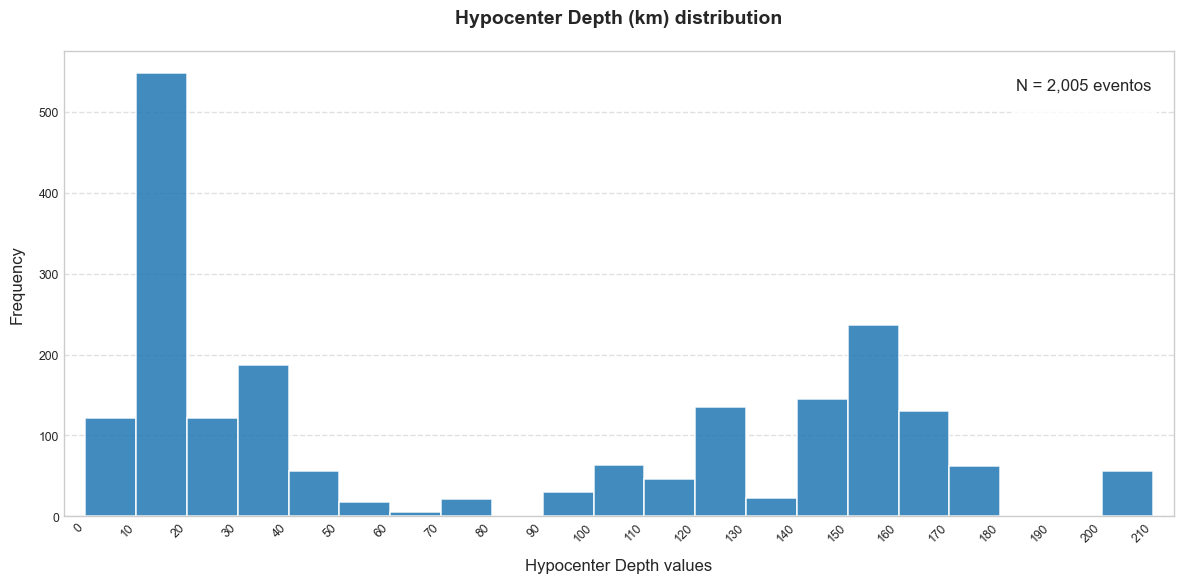

In [39]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12
plt.figure(figsize=(12, 6), dpi=100)
bin_width = 10  
max_depth = np.ceil(df2["Hypocenter Depth (km)"].max() / 10) * 10
bins = np.arange(0, max_depth + bin_width, bin_width)
plt.hist(
    df2["Hypocenter Depth (km)"].dropna(),
    bins=bins,
    color='#1f77b4',  # Azul mejorado
    edgecolor='white',  # Borde blanco para mejor contraste
    linewidth=1.2,  # Grosor del borde
    alpha=0.85  # Ligera transparencia
)
ax = plt.gca()
ax.set_xticks(bins)  # Mostrar todas las divisiones principales
ax.set_xticks(np.arange(0, max_depth + 5, 5), minor=True)  # Marcas menores cada 5 km
plt.xticks(rotation=45, ha='right')  # Alineación a la derecha
plt.title(
    "Hypocenter Depth (km) distribution",
    pad=20,
    fontweight='bold',
    fontsize=14
)
plt.xlabel("Hypocenter Depth values", labelpad=10)
plt.ylabel("Frequency", labelpad=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.6)  # Solo grid horizontal
ax.xaxis.grid(False) 

stats_text = f"""
N = {len(df2["Hypocenter Depth (km)"].dropna()):,} eventos
"""
plt.annotate(
    stats_text,
    xy=(0.98, 0.98),
    xycoords='axes fraction',
    ha='right',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.margins(x=0.02)  
plt.tight_layout()
plt.show()

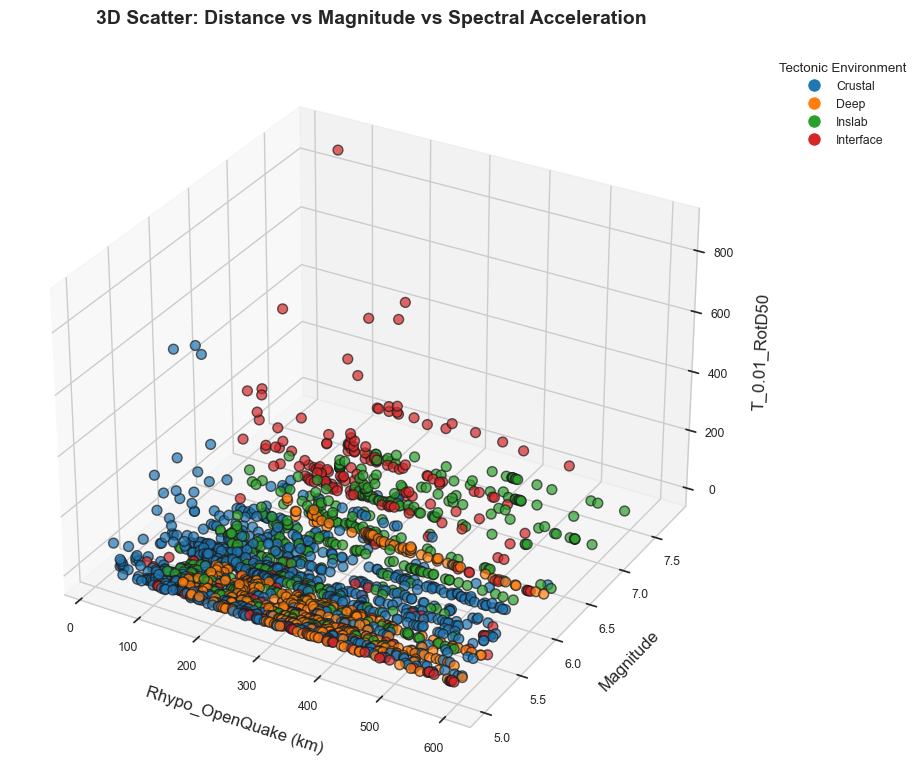

In [40]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Preparar datos
x = df2["Rhypo_OpenQuake"]
y = df2["Magnitude"]
z = df2["T_0.01_RotD50"]
envs = df2["Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"]

# Asignar un color a cada ambiente tectónico
unique_envs = envs.unique()
color_dict = {env: plt.cm.tab10(i) for i, env in enumerate(unique_envs)}
colors = envs.map(color_dict)

# Crear el plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x, y, z, c=colors, s=50, alpha=0.7, edgecolor='k')

# Ejes y título
ax.set_xlabel("Rhypo_OpenQuake (km)", labelpad=10)
ax.set_ylabel("Magnitude", labelpad=10)
ax.set_zlabel("T_0.01_RotD50", labelpad=10)
ax.set_title("3D Scatter: Distance vs Magnitude vs Spectral Acceleration", pad=20, fontweight='bold')

# Crear leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                          label=env, markerfacecolor=color_dict[env], markersize=10)
                   for env in unique_envs]
ax.legend(handles=legend_elements, title="Tectonic Environment", loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


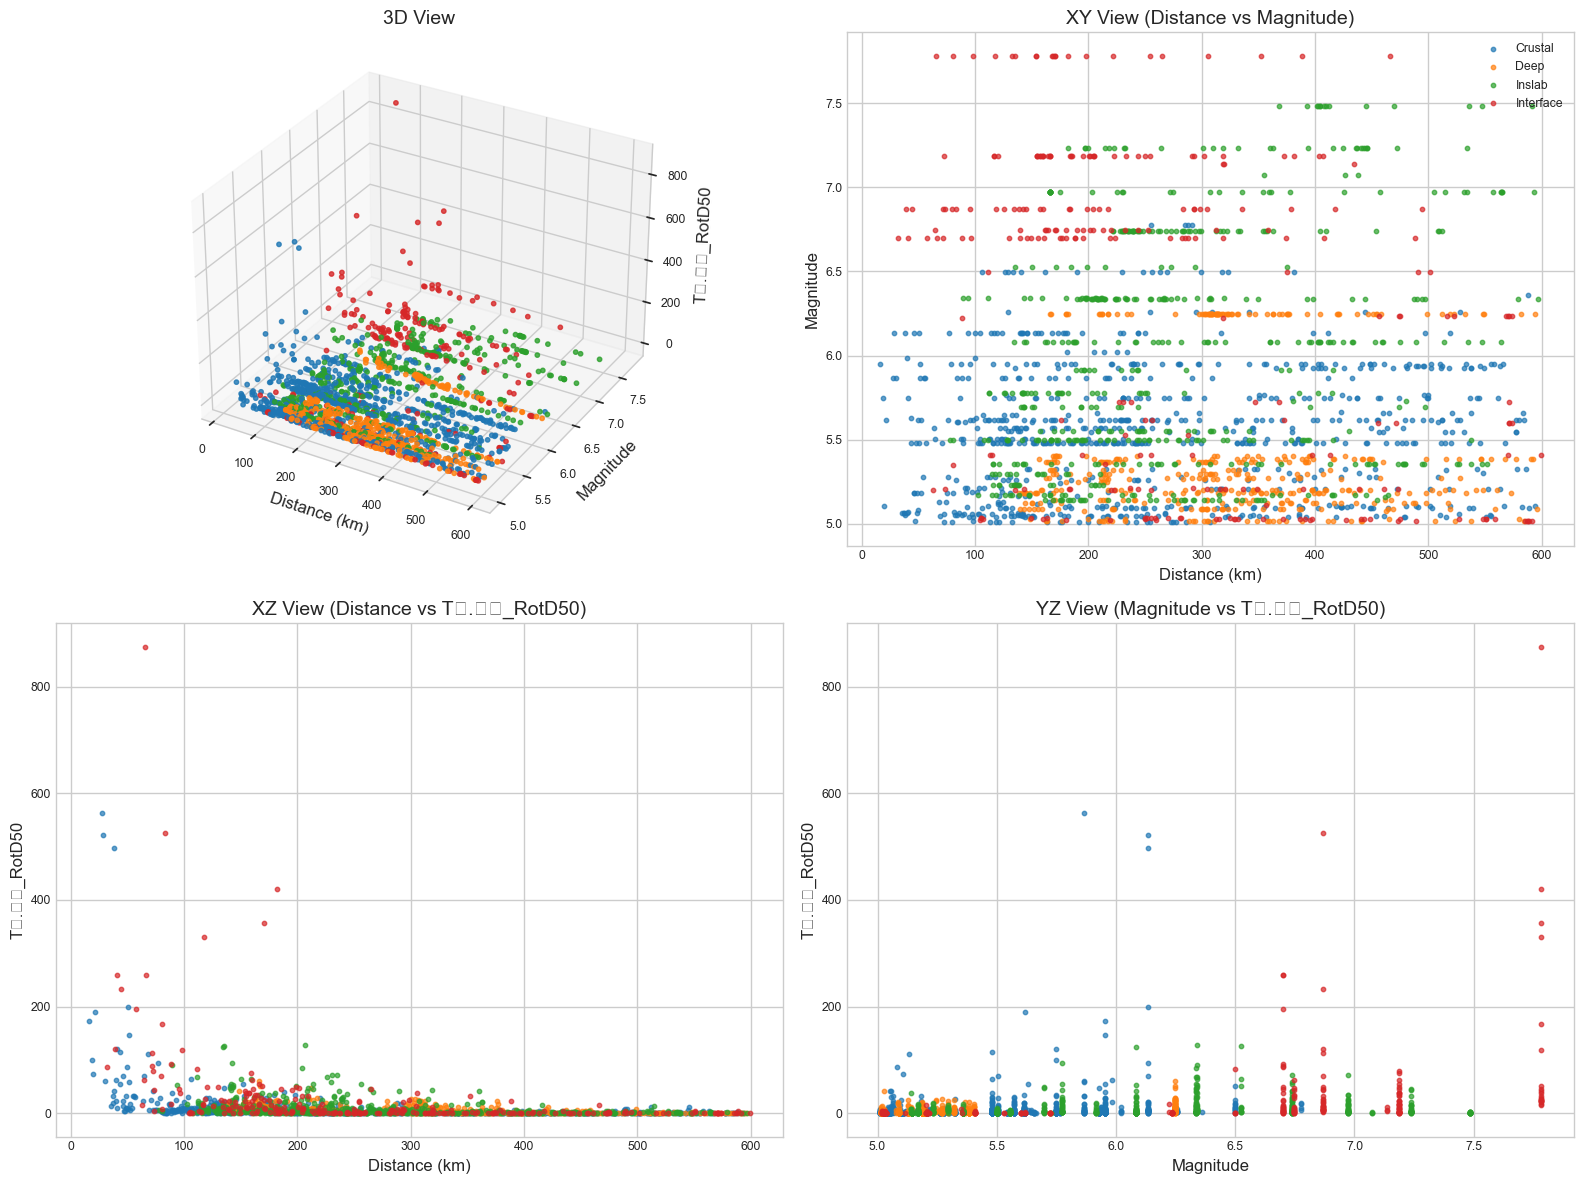

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Elimina valores nulos
df_plot = df2[["Rhypo_OpenQuake", "Magnitude", "T_0.01_RotD50",
               "Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"]].dropna()

# Renombrar para facilitar
df_plot = df_plot.rename(columns={
    "Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)": "Tectonic_Env"
})

# Paleta de colores por ambiente tectónico
envs = df_plot["Tectonic_Env"].unique()
palette = dict(zip(envs, sns.color_palette("tab10", len(envs))))
colors = df_plot["Tectonic_Env"].map(palette)

# Crear figura con 2x2 subplots
fig = plt.figure(figsize=(16, 12))

# --- Vista 3D ---
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(
    df_plot["Rhypo_OpenQuake"], df_plot["Magnitude"], df_plot["T_0.01_RotD50"],
    c=colors, s=10, alpha=0.8
)
ax1.set_xlabel("Distance (km)")
ax1.set_ylabel("Magnitude")
ax1.set_zlabel("T₀.₀₁_RotD50")
ax1.set_title("3D View")

# --- Vista XY ---
ax2 = fig.add_subplot(222)
for env in envs:
    subset = df_plot[df_plot["Tectonic_Env"] == env]
    ax2.scatter(subset["Rhypo_OpenQuake"], subset["Magnitude"], color=palette[env], s=10, label=env, alpha=0.7)
ax2.set_xlabel("Distance (km)")
ax2.set_ylabel("Magnitude")
ax2.set_title("XY View (Distance vs Magnitude)")
ax2.legend(loc='upper right')

# --- Vista XZ ---
ax3 = fig.add_subplot(223)
for env in envs:
    subset = df_plot[df_plot["Tectonic_Env"] == env]
    ax3.scatter(subset["Rhypo_OpenQuake"], subset["T_0.01_RotD50"], color=palette[env], s=10, alpha=0.7)
ax3.set_xlabel("Distance (km)")
ax3.set_ylabel("T₀.₀₁_RotD50")
ax3.set_title("XZ View (Distance vs T₀.₀₁_RotD50)")

# --- Vista YZ ---
ax4 = fig.add_subplot(224)
for env in envs:
    subset = df_plot[df_plot["Tectonic_Env"] == env]
    ax4.scatter(subset["Magnitude"], subset["T_0.01_RotD50"], color=palette[env], s=10, alpha=0.7)
ax4.set_xlabel("Magnitude")
ax4.set_ylabel("T₀.₀₁_RotD50")
ax4.set_title("YZ View (Magnitude vs T₀.₀₁_RotD50)")

plt.tight_layout()
plt.show()


In [42]:
import plotly.express as px

# Asegúrate de que no haya valores nulos en las columnas necesarias
df_plot = df2[["Rhypo_OpenQuake", "Magnitude", "T_0.01_RotD50",
               "Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"]].dropna()

# Renombrar la columna de ambiente tectónico para que no sea tan larga en el gráfico
df_plot = df_plot.rename(columns={
    "Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)": "Tectonic Environment"
})

# Crear gráfico interactivo
fig = px.scatter_3d(
    df_plot,
    x="Rhypo_OpenQuake",
    y="Magnitude",
    z="T_0.01_RotD50",
    color="Tectonic Environment",
    opacity=0.7,
    size_max=8,
    title="3D Scatter Plot: Distance vs Magnitude vs T_0.01_RotD50",
    labels={
        "Rhypo_OpenQuake": "Hypocentral Distance (km)",
        "Magnitude": "Magnitude",
        "T_0.01_RotD50": "Spectral Acceleration (T=0.01s)",
        "Tectonic Environment": "Tectonic Environment"
    }
)

# Mejoras visuales
fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(scene=dict(
    xaxis_title='Distance (km)',
    yaxis_title='Magnitude',
    zaxis_title='T_0.01_RotD50'),
    legend=dict(itemsizing='constant'))

# Mostrar
fig.show()


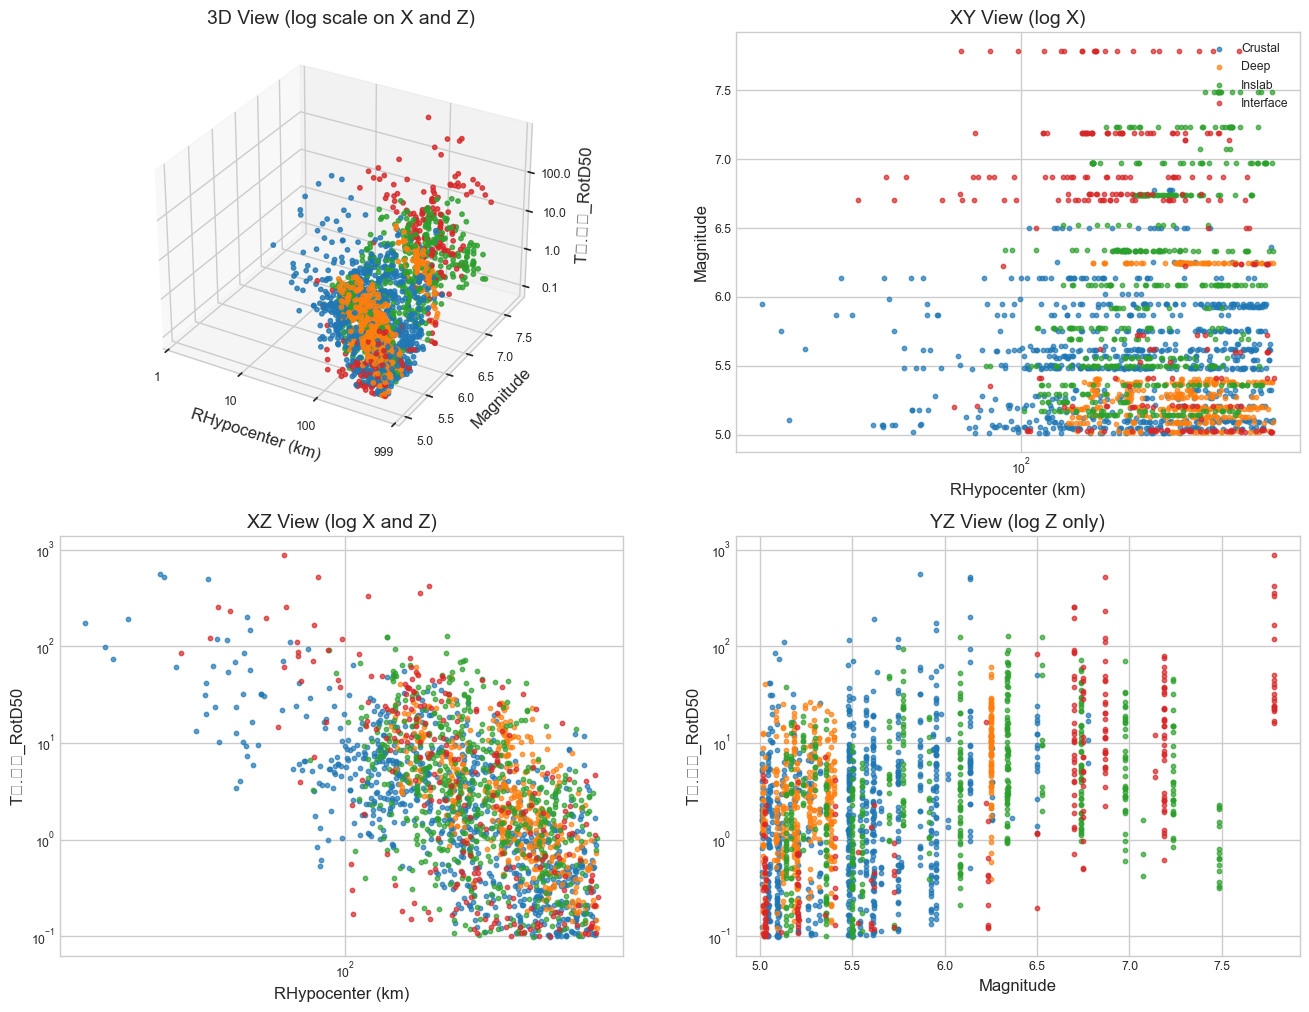

In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import numpy as np

# Elimina valores nulos y valores <= 0
df_plot = df2[["Rhypo_OpenQuake", "Magnitude", "T_0.01_RotD50",
               "Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"]].dropna()

df_plot = df_plot[
    (df_plot["Rhypo_OpenQuake"] > 0) & 
    (df_plot["T_0.01_RotD50"] > 0)
]

# Renombrar para facilitar
df_plot = df_plot.rename(columns={
    "Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)": "Tectonic_Env"
})

# Transformar las columnas para simular escala log
df_plot["log_RHypo"] = np.log(df_plot["Rhypo_OpenQuake"])
df_plot["log_T_0.01"] = np.log(df_plot["T_0.01_RotD50"])

# Paleta de colores por ambiente tectónico
envs = df_plot["Tectonic_Env"].unique()
palette = dict(zip(envs, sns.color_palette("tab10", len(envs))))
colors = df_plot["Tectonic_Env"].map(palette)

# Crear figura con 2x2 subplots
fig = plt.figure(figsize=(16, 12))

# --- Vista 3D ---
ax1 = fig.add_subplot(221, projection='3d')
sc = ax1.scatter(
    df_plot["log_RHypo"], df_plot["Magnitude"], df_plot["log_T_0.01"],
    c=colors, s=10, alpha=0.8
)

ax1.set_xlabel("RHypocenter (km)")
ax1.set_ylabel("Magnitude")
ax1.set_zlabel("T₀.₀₁_RotD50")

ax1.set_title("3D View (log scale on X and Z)")

# Ajustar ticks y etiquetas en X
ticks_log_x = np.log([1, 10, 100, 1000])
ax1.set_xticks(ticks_log_x)
ax1.set_xticklabels([str(int(np.exp(t))) for t in ticks_log_x])

# Ajustar ticks y etiquetas en Z
ticks_log_z = np.log([0.1, 1, 10, 100])  # Ajusta según rango de T_0.01_RotD50
ax1.set_zticks(ticks_log_z)
ax1.set_zticklabels([f"{np.exp(t):.1f}" for t in ticks_log_z])

# --- Vista XY ---
ax2 = fig.add_subplot(222)
for env in envs:
    subset = df_plot[df_plot["Tectonic_Env"] == env]
    ax2.scatter(subset["Rhypo_OpenQuake"], subset["Magnitude"], color=palette[env], s=10, label=env, alpha=0.7)
ax2.set_xscale('log')
ax2.set_xlabel("RHypocenter (km)")
ax2.set_ylabel("Magnitude")
ax2.set_title("XY View (log X)")
ax2.legend(loc='upper right')

# --- Vista XZ ---
ax3 = fig.add_subplot(223)
for env in envs:
    subset = df_plot[df_plot["Tectonic_Env"] == env]
    ax3.scatter(subset["Rhypo_OpenQuake"], subset["T_0.01_RotD50"], color=palette[env], s=10, alpha=0.7)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel("RHypocenter (km)")
ax3.set_ylabel("T₀.₀₁_RotD50")
ax3.set_title("XZ View (log X and Z)")

# --- Vista YZ ---
ax4 = fig.add_subplot(224)
for env in envs:
    subset = df_plot[df_plot["Tectonic_Env"] == env]
    ax4.scatter(subset["Magnitude"], subset["T_0.01_RotD50"], color=palette[env], s=10, alpha=0.7)
    
ax4.set_yscale('log')
ax4.set_xlabel("Magnitude")
ax4.set_ylabel("T₀.₀₁_RotD50")
ax4.set_title("YZ View (log Z only)")

plt.tight_layout()
plt.show()
